In [ ]:
import sys

print("Python version:", sys.version)
print("Python path:", sys.executable)

Python version: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Python path: C:\Users\T9951\Documents\ServiceSense_AI\.venv\Scripts\python.exe


In [ ]:
%pip install pandas numpy scikit-learn matplotlib joblib

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.8 MB 730.2 kB/s eta 0:00:13
   -- ------------------------------------- 0.5/9.8 MB 730.2 kB/s eta 0:00:13
   --- ------------------------------------ 0.8/9.8 MB 819.2 kB/s eta 0:00:12
   ---- ----------------------------------- 1.0/9.8 MB 883.6 kB/s eta 0:00:10
   ------ --------------------------------- 1.6/9.8 MB 1.1 MB/s eta 0:00:08
   ------- -------------------------------- 1.8/9.8 MB 1.2 MB/s eta 0:00:07
   -------- ------------------------------- 2.1/9.8 MB 1.2 MB/s eta 0:00:07
   ---------- ----------------------------- 2.6/9.8 MB 1.3 MB/s eta 0:00:06
   ----------- ------------------------

In [ ]:
%pip install sentence-transformers faiss-cpu langchain langchain-openai

   ---------------------------------------- 0.0/739.6 kB ? eta -:--:--
   -------------- ------------------------- 262.1/739.6 kB ? eta -:--:--
   ---------------------------------------- 739.6/739.6 kB 2.0 MB/s  0:00:00
   ---------------------------------------- 0.0/795.8 kB ? eta -:--:--
   -------------------------- ------------- 524.3/795.8 kB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 795.8/795.8 kB 3.8 MB/s  0:00:00
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ------- -------------------------------- 0.8/4.0 MB 3.7 MB/s eta 0:00:01
   --------------- ------------------------ 1.6/4.0 MB 3.8 MB/s eta 0:00:01
   -------------------- ------------------- 2.1/4.0 MB 4.2 MB/s eta 0:00:01
   ---------------------------- ----------- 2.9/4.0 MB 3.6 MB/s eta 0:00:01
   ------------------------------------ --- 3.7/4.0 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 4.0/4.0 MB 3.5 MB/s  0:00:01
   --------------------------

In [ ]:
%pip install openai python-dotenv mlflow flask

   ---------------------------------------- 0.0/11.2 MB ? eta -:--:--
    --------------------------------------- 0.3/11.2 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.2 MB 1.0 MB/s eta 0:00:11
   -- ------------------------------------- 0.8/11.2 MB 1.2 MB/s eta 0:00:09
   -- ------------------------------------- 0.8/11.2 MB 1.2 MB/s eta 0:00:09
   -- ------------------------------------- 0.8/11.2 MB 1.2 MB/s eta 0:00:09
   ---- ----------------------------------- 1.3/11.2 MB 1.0 MB/s eta 0:00:10
   ----- ---------------------------------- 1.6/11.2 MB 1.1 MB/s eta 0:00:09
   ------- -------------------------------- 2.1/11.2 MB 1.2 MB/s eta 0:00:08
   -------- ------------------------------- 2.4/11.2 MB 1.3 MB/s eta 0:00:07
   ---------- ----------------------------- 2.9/11.2 MB 1.4 MB/s eta 0:00:07
   ----------- ---------------------------- 3.1/11.2 MB 1.4 MB/s eta 0:00:06
   ------------- -------------------------- 3.7/11.2 MB 1.5 MB/s eta 0:00:06
   ----------

In [ ]:
# Cell 1 - Import Libraries

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Cell 2 - Load ServiceSense Dataset

df = pd.read_csv("data/ServiceSenseAI.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (26872, 5)


In [ ]:
# Cell 3 - Preview Dataset

df.head()

,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [ ]:
# Cell 4 - Dataset Information

print("Column Names:")

for i, column in enumerate(df.columns, start=1):
    print(i, column)

print("\nDataset Information:")
df.info()

Column Names:
1 flags
2 instruction
3 category
4 intent
5 response

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   flags        26872 non-null  object
 1   instruction  26872 non-null  object
 2   category     26872 non-null  object
 3   intent       26872 non-null  object
 4   response     26872 non-null  object
dtypes: object(5)
memory usage: 1.0+ MB


In [ ]:
# Cell 5 - Check Missing Values

print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
flags          0
instruction    0
category       0
intent         0
response       0
dtype: int64

Duplicate Rows:
0


In [ ]:
# Cell 6 - Select Required Columns

df_selected = df[
    ["instruction", "category", "intent", "response"]
].copy()

print("Selected dataset shape:", df_selected.shape)

df_selected.head()

Selected dataset shape: (26872, 4)


,instruction,category,intent,response
0,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [ ]:
# Cell 7 - Category Analysis

print("Number of Categories:", df_selected["category"].nunique())

print("\nCategory Distribution:")
print(df_selected["category"].value_counts())

Number of Categories: 11

Category Distribution:
category
ACCOUNT         5986
ORDER           3988
REFUND          2992
CONTACT         1999
INVOICE         1999
PAYMENT         1998
FEEDBACK        1997
DELIVERY        1994
SHIPPING        1970
SUBSCRIPTION     999
CANCEL           950
Name: count, dtype: int64


In [ ]:
# Cell 8 - Intent Analysis

print("Number of Intents:", df_selected["intent"].nunique())

print("\nIntent Distribution:")
print(df_selected["intent"].value_counts())

Number of Intents: 27

Intent Distribution:
intent
contact_customer_service    1000
complaint                   1000
check_invoice               1000
switch_account              1000
edit_account                1000
contact_human_agent          999
check_payment_methods        999
delivery_period              999
newsletter_subscription      999
get_invoice                  999
payment_issue                999
registration_problems        999
cancel_order                 998
place_order                  998
track_refund                 998
change_order                 997
set_up_shipping_address      997
check_refund_policy          997
create_account               997
get_refund                   997
review                       997
delivery_options             995
delete_account               995
recover_password             995
track_order                  995
change_shipping_address      973
check_cancellation_fee       950
Name: count, dtype: int64


In [ ]:
# Cell 9 - Category Intent Relationship

category_intent = (
    df_selected[["category", "intent"]]
    .drop_duplicates()
    .sort_values(["category", "intent"])
)

category_intent

,category,intent
9913,ACCOUNT,create_account
10910,ACCOUNT,delete_account
13899,ACCOUNT,edit_account
19891,ACCOUNT,recover_password
20886,ACCOUNT,registration_problems
23879,ACCOUNT,switch_account
2968,CANCEL,check_cancellation_fee
7914,CONTACT,contact_customer_service
8914,CONTACT,contact_human_agent
11905,DELIVERY,delivery_options


In [ ]:
# Cell 10 - View Complaint Examples

pd.set_option("display.max_colwidth", None)

df_selected[
    ["instruction", "category", "intent", "response"]
].sample(10, random_state=42)

,instruction,category,intent,response
9329,I can't talk with a human agent,CONTACT,contact_human_agent,Thank you for reaching out! I'm sorry to hear that you're facing difficulties in connecting with a human agent. Please rest assured that I'm here to assist you and resolve this issue. Could you please provide me with some more details about the problem you're experiencing? This will help me find the best solution for you.
4160,I have got to locate hte bills from {{Person Name}},INVOICE,check_invoice,"I'll get right on it! I understand your need to locate the bills associated with {{Person Name}}. To assist you in finding the relevant invoices, could you please provide me with some additional details such as the date range or any other specific information that might help narrow down the search? Rest assured, I'm here to guide you every step of the way and ensure a seamless experience."
18500,"I cannot pay, help me to inform of a problem with payments",PAYMENT,payment_issue,"I apologize for the inconvenience caused by the payment issue you're experiencing. I understand how frustrating it can be when you encounter difficulties while trying to make a payment. Rest assured, I'm here to assist you in resolving this problem. To help us further investigate and address the issue, could you please provide more details about the problem you are encountering? Any specific error messages or steps leading up to the issue would be helpful. Your input is valuable, and we're committed to finding a solution together. Thank you for bringing this to our attention, and we'll work diligently to get it sorted."
8840,I want help speaking to customer service,CONTACT,contact_customer_service,"Grateful for your contact! I get the sense that you're looking for assistance in speaking to our customer service team. I'm here to guide you through the process and ensure that you have a seamless experience. To connect with our customer service, you can reach them during {{Customer Support Hours}}. If you have any other questions, concerns, or experiences you'd like to share, please feel free to let me know. I'm here to help!"
5098,I try to see th accepted payment options,PAYMENT,check_payment_methods,"Thank you for reaching out! I completely understand that you tried to access the accepted payment options on our platform. I apologize for any inconvenience caused. Allow me to assist you in viewing our available payment methods.\n\nTo check the accepted payment options, you can visit our website's ""Payment"" or ""Checkout"" page. There, you will find a comprehensive list of the various payment methods we accept. If you encounter any difficulties or have further questions, please don't hesitate to let me know.\n\nYour satisfaction is our priority, and I'm here to ensure a seamless payment experience for you."
17250,where to sign up to the company nmewsletter,SUBSCRIPTION,newsletter_subscription,"Thank you for your interest in signing up for our company newsletter! To subscribe, you can visit our website at {{Website URL}} and navigate to the newsletter section. There you will find a sign-up form where you can enter your email address and other required information. Once you submit the form, you will be successfully subscribed to our newsletter and receive regular updates directly in your inbox. If you require any further assistance or have any questions, please don't hesitate to let me know."
3589,I'd like to see the withdrwaal fee how can i do it,CANCEL,check_cancellation_fee,"I'll do my best! To view the withdrawal fee, you can log in to your account and navigate to the ""Fee Schedule"" or ""Account Charges"" section. This will provide you with the details of the withdrawal fee and any associated charges."
9043,I want to speak with someone,CONTACT,contact_human_agent,"I see what you mean! I'm on the same page that you would like to speak with someone. Your request is important, and I'm here to help. Let me quickly connect you with a human representative who w

In [ ]:
# Cell 11 - Text Preprocessing

import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_selected["clean_instruction"] = (
    df_selected["instruction"].apply(clean_text)
)

df_selected[
    ["instruction", "clean_instruction", "intent"]
].head()

,instruction,clean_instruction,intent
0,question about cancelling order {{Order Number}},question about cancelling order order number,cancel_order
1,i have a question about cancelling oorder {{Order Number}},i have a question about cancelling oorder order number,cancel_order
2,i need help cancelling puchase {{Order Number}},i need help cancelling puchase order number,cancel_order
3,I need to cancel purchase {{Order Number}},i need to cancel purchase order number,cancel_order
4,"I cannot afford this order, cancel purchase {{Order Number}}",i cannot afford this order cancel purchase order number,cancel_order


In [ ]:
# Cell 12 - Define ML Input and Target

X = df_selected["clean_instruction"]
y = df_selected["intent"]

print("Total records:", len(X))
print("Number of intent classes:", y.nunique())

Total records: 26872
Number of intent classes: 27


In [ ]:
# Cell 13 - Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 21497
Testing records: 5375


In [ ]:
# Cell 14 - TF-IDF Vectorization

tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    stop_words="english",
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF completed successfully!")
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

TF-IDF completed successfully!
Training shape: (21497, 11556)
Testing shape: (5375, 11556)


In [ ]:
# Cell 15 - Train Logistic Regression

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(
    X_train_tfidf,
    y_train
)

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [ ]:
# Cell 16 - Evaluate Logistic Regression

lr_predictions = logistic_model.predict(
    X_test_tfidf
)

lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

print(
    "Logistic Regression Accuracy:",
    round(lr_accuracy * 100, 2),
    "%"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        lr_predictions,
        zero_division=0
    )
)

Logistic Regression Accuracy: 97.82 %

Classification Report:
                          precision    recall  f1-score   support

            cancel_order       1.00      0.95      0.97       200
            change_order       0.92      0.98      0.95       199
 change_shipping_address       0.98      1.00      0.99       195
  check_cancellation_fee       1.00      1.00      1.00       190
           check_invoice       0.83      0.88      0.85       200
   check_payment_methods       1.00      1.00      1.00       200
     check_refund_policy       1.00      0.99      1.00       199
               complaint       1.00      1.00      1.00       200
contact_customer_service       1.00      0.98      0.99       200
     contact_human_agent       0.99      0.98      0.99       200
          create_account       0.99      0.97      0.98       199
          delete_account       0.93      0.99      0.96       199
        delivery_options       1.00      1.00      1.00       199
         deli

In [ ]:
# Cell 17 - Train Random Forest

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_tfidf,
    y_train
)

print("Random Forest training completed!")

Random Forest training completed!


In [ ]:
# Cell 18 - Evaluate Random Forest

rf_predictions = random_forest_model.predict(
    X_test_tfidf
)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print(
    "Random Forest Accuracy:",
    round(rf_accuracy * 100, 2),
    "%"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        rf_predictions,
        zero_division=0
    )
)

Random Forest Accuracy: 97.69 %

Classification Report:
                          precision    recall  f1-score   support

            cancel_order       0.99      0.98      0.98       200
            change_order       0.98      0.96      0.97       199
 change_shipping_address       0.97      0.99      0.98       195
  check_cancellation_fee       1.00      1.00      1.00       190
           check_invoice       0.79      0.86      0.83       200
   check_payment_methods       1.00      0.98      0.99       200
     check_refund_policy       1.00      0.99      0.99       199
               complaint       1.00      1.00      1.00       200
contact_customer_service       1.00      0.98      0.99       200
     contact_human_agent       0.97      0.99      0.98       200
          create_account       0.97      0.98      0.98       199
          delete_account       0.99      0.98      0.99       199
        delivery_options       0.98      1.00      0.99       199
         delivery_p

In [ ]:
# Cell 19 - Model Comparison

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy (%)": [
        round(lr_accuracy * 100, 2),
        round(rf_accuracy * 100, 2)
    ]
})

model_comparison = model_comparison.sort_values(
    "Accuracy (%)",
    ascending=False
)

model_comparison

,Model,Accuracy (%)
0,Logistic Regression,97.82
1,Random Forest,97.69


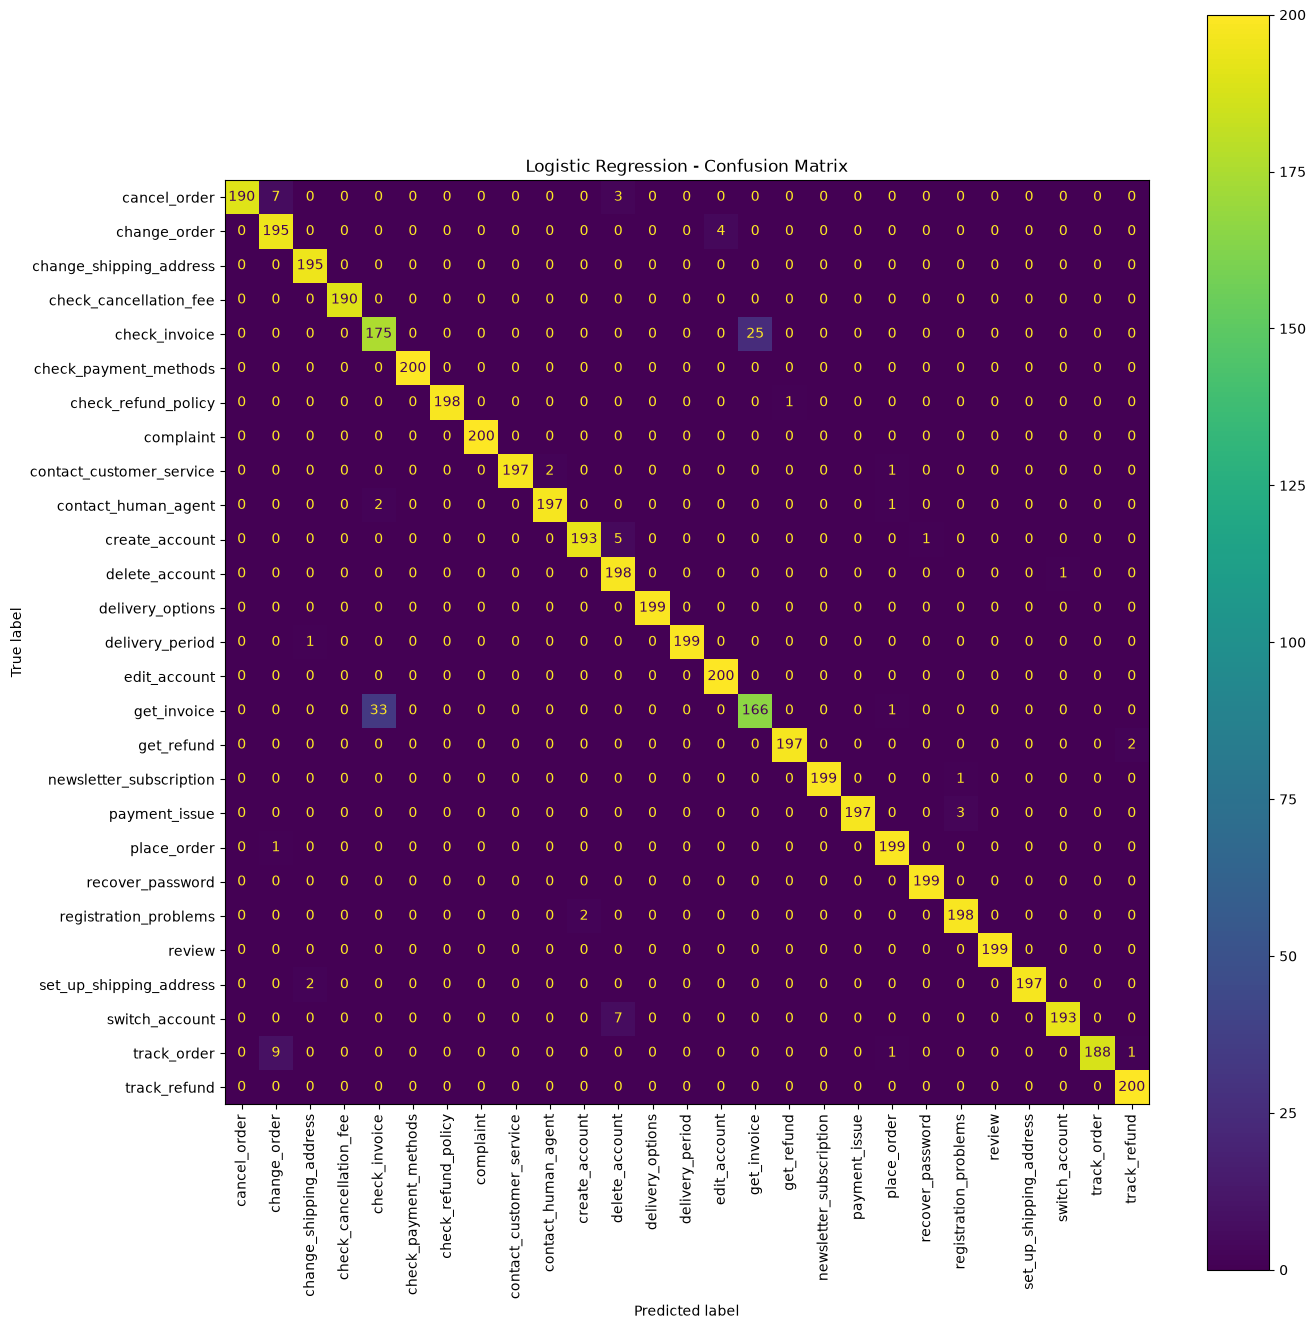

In [ ]:
# Cell 20 - Logistic Regression Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 14))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_predictions,
    xticks_rotation=90,
    ax=ax
)

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# Cell 21 - Select Best Model

if lr_accuracy >= rf_accuracy:
    best_model = logistic_model
    best_model_name = "Logistic Regression"
    best_accuracy = lr_accuracy
else:
    best_model = random_forest_model
    best_model_name = "Random Forest"
    best_accuracy = rf_accuracy

print("Best Model:", best_model_name)
print("Best Accuracy:", round(best_accuracy * 100, 2), "%")

Best Model: Logistic Regression
Best Accuracy: 97.82 %


In [ ]:
# Cell 22 - Save Trained Model

import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(
    best_model,
    "models/intent_classifier.pkl"
)

joblib.dump(
    tfidf,
    "models/tfidf_vectorizer.pkl"
)

print("Model saved successfully!")
print("TF-IDF vectorizer saved successfully!")

Model saved successfully!
TF-IDF vectorizer saved successfully!


In [ ]:
# Cell 23 - Test Intent Prediction

def predict_intent(complaint):

    cleaned = clean_text(complaint)

    vector = tfidf.transform([cleaned])

    prediction = best_model.predict(vector)[0]

    return prediction


test_complaint = "I forgot my password and cannot access my account"

predicted_intent = predict_intent(test_complaint)

print("Customer Complaint:")
print(test_complaint)

print("\nPredicted Intent:")
print(predicted_intent)

Customer Complaint:
I forgot my password and cannot access my account

Predicted Intent:
recover_password


In [ ]:
predict_intent("Where is my refund?")

'track_refund'

In [ ]:
import os

git_path = r"C:\Program Files\Git\mingw64\bin\git.exe"

print("Git exists:", os.path.exists(git_path))

Git exists: True


In [ ]:
import subprocess

result = subprocess.run(
    [git_path, "--version"],
    capture_output=True,
    text=True
)

print(result.stdout)

git version 2.54.0.windows.1



In [ ]:
# Cell 28 - Initialize MLflow

import os

os.environ["GIT_PYTHON_GIT_EXECUTABLE"] = git_path
os.environ["GIT_PYTHON_REFRESH"] = "quiet"

import mlflow
import mlflow.sklearn

mlflow.set_experiment("ServiceSense_AI")

print("MLflow initialized successfully!")

MLflow initialized successfully!


In [ ]:
# Cell 29 - Track Logistic Regression

with mlflow.start_run(run_name="Logistic_Regression"):

    mlflow.log_param("model_name", "Logistic Regression")
    mlflow.log_param("max_iter", 2000)
    mlflow.log_param("tfidf_max_features", 15000)
    mlflow.log_param("ngram_range", "1,2")

    mlflow.log_metric("accuracy", lr_accuracy)

    mlflow.sklearn.log_model(
        logistic_model,
        name="logistic_regression_model"
    )

print("Logistic Regression experiment logged successfully!")

Logistic Regression experiment logged successfully!


In [ ]:
# Cell 30 - Track Random Forest

with mlflow.start_run(run_name="Random_Forest"):

    mlflow.log_param("model_name", "Random Forest")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("tfidf_max_features", 15000)

    mlflow.log_metric("accuracy", rf_accuracy)

    mlflow.sklearn.log_model(
        random_forest_model,
        name="random_forest_model"
    )

print("Random Forest experiment logged successfully!")

Random Forest experiment logged successfully!


In [ ]:
# Cell 31 - MLflow Model Comparison

experiment = mlflow.get_experiment_by_name(
    "ServiceSense_AI"
)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

comparison_mlflow = runs[
    [
        "tags.mlflow.runName",
        "metrics.accuracy"
    ]
].copy()

comparison_mlflow["Accuracy (%)"] = (
    comparison_mlflow["metrics.accuracy"] * 100
).round(2)

comparison_mlflow[
    ["tags.mlflow.runName", "Accuracy (%)"]
]

,tags.mlflow.runName,Accuracy (%)
0,Random_Forest,97.69
1,Logistic_Regression,97.82
2,Logistic_Regression,97.82


In [ ]:
# Cell 32 - Best Model Summary

best_run = comparison_mlflow.sort_values(
    "Accuracy (%)",
    ascending=False
).iloc[0]

print("Best Model:", best_run["tags.mlflow.runName"])
print("Accuracy:", best_run["Accuracy (%)"], "%")

Best Model: Logistic_Regression
Accuracy: 97.82 %


In [ ]:
# Cell 33 - Import RAG Libraries

from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

print("RAG libraries imported successfully!")

RAG libraries imported successfully!


In [ ]:
# Cell 34 - Test Hugging Face Access

from huggingface_hub import hf_hub_download

test_file = hf_hub_download(
    repo_id="sentence-transformers/all-MiniLM-L6-v2",
    filename="config.json"
)

print("Hugging Face Python access working!")
print(test_file)

Hugging Face Python access working!
C:\Users\T9951\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2\snapshots\1110a243fdf4706b3f48f1d95db1a4f5529b4d41\config.json


In [ ]:
%pip install pip-system-certs

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Cell 35A - Test Hugging Face after certificate fix

from huggingface_hub import hf_hub_download

test_file = hf_hub_download(
    repo_id="sentence-transformers/all-MiniLM-L6-v2",
    filename="config.json",
    force_download=True
)

print("Hugging Face certificate test passed!")
print(test_file)

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

Hugging Face certificate test passed!
C:\Users\T9951\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2\snapshots\1110a243fdf4706b3f48f1d95db1a4f5529b4d41\config.json


In [ ]:
# Cell 35A - Disable Hugging Face Xet

import os

os.environ["HF_HUB_DISABLE_XET"] = "1"

print("Xet disabled:", os.environ["HF_HUB_DISABLE_XET"])

Xet disabled: 1


In [ ]:
%whos

Variable              Type       Data/Info
------------------------------------------
SentenceTransformer   ABCMeta    <class 'sentence_transfor<...>del.SentenceTransformer'>
faiss                 module     <module 'faiss' from 'C:\<...>ges\\faiss\\__init__.py'>
np                    module     <module 'numpy' from 'C:\<...>ges\\numpy\\__init__.py'>


In [ ]:
import pandas as pd

df = pd.read_csv("data/ServiceSenseAI.csv")

print(df.shape)
print(df.columns.tolist())

(26872, 5)
['flags', 'instruction', 'category', 'intent', 'response']


In [ ]:
df_selected = df[
    ["instruction", "category", "intent", "response"]
].copy()

print(df_selected.shape)

(26872, 4)


In [ ]:
import joblib

tfidf = joblib.load(
    "models/tfidf_vectorizer.pkl"
)

print("TF-IDF loaded successfully!")

TF-IDF loaded successfully!


In [ ]:
print("Dataset:", df_selected.shape)
print("TF-IDF:", tfidf)

Dataset: (26872, 4)
TF-IDF: TfidfVectorizer(max_features=15000, ngram_range=(1, 2), stop_words='english',
                sublinear_tf=True)


In [ ]:
# Cell 35 - Create RAG TF-IDF Vectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

rag_tfidf = TfidfVectorizer(
    max_features=2000,
    stop_words="english",
    ngram_range=(1, 2)
)

rag_vectors = rag_tfidf.fit_transform(
    df_selected["instruction"]
)

print("RAG TF-IDF shape:", rag_vectors.shape)

RAG TF-IDF shape: (26872, 2000)


In [ ]:
# Cell 36 - Prepare FAISS Vectors

rag_vectors_dense = rag_vectors.toarray().astype("float32")

print("Dense vector shape:", rag_vectors_dense.shape)
print("Data type:", rag_vectors_dense.dtype)

Dense vector shape: (26872, 2000)
Data type: float32


In [ ]:
# Cell 37 - Normalize RAG Vectors

import faiss

faiss.normalize_L2(rag_vectors_dense)

print("Vectors normalized successfully!")

Vectors normalized successfully!


In [ ]:
# Cell 38 - Build FAISS Index

dimension = rag_vectors_dense.shape[1]

faiss_index = faiss.IndexFlatIP(dimension)

faiss_index.add(rag_vectors_dense)

print("FAISS index created successfully!")
print("Total vectors:", faiss_index.ntotal)

FAISS index created successfully!
Total vectors: 26872


In [ ]:
# Cell 39 - Retrieve Similar Complaints

def retrieve_similar_complaints(query, top_k=3):

    query_vector = rag_tfidf.transform([query]).toarray().astype("float32")

    faiss.normalize_L2(query_vector)

    scores, indices = faiss_index.search(
        query_vector,
        top_k
    )

    results = []

    for score, idx in zip(scores[0], indices[0]):

        row = df_selected.iloc[idx]

        results.append({
            "score": float(score),
            "instruction": row["instruction"],
            "category": row["category"],
            "intent": row["intent"],
            "response": row["response"]
        })

    return results

In [ ]:
# Cell 40 - Test RAG Retrieval

test_query = "I forgot my password and cannot login"

results = retrieve_similar_complaints(
    test_query,
    top_k=3
)

for i, result in enumerate(results, 1):

    print(f"\nResult {i}")

    print("Similarity:", round(result["score"], 3))
    print("Complaint:", result["instruction"])
    print("Intent:", result["intent"])
    print("Response:", result["response"])


Result 1
Similarity: 0.702
Complaint: I forgot my account password, how t reset it?
Intent: recover_password
Response: Oh, I completely understand how frustrating it can be to forget your account password. Don't worry, I'm here to assist you in the process of resetting it so you can regain access to your account. Here's what you can do:

1. First and foremost, visit our login page at "{{Login Page URL}}" to initiate the password reset process.
2. Look for the option that says "{{Forgot Password}}" and click on it.
3. You will be prompted to enter the email address associated with your account. Please provide the correct email address to proceed.
4. Once you've entered your email address, an email will be sent to you shortly with instructions on how to reset your password. Please check your inbox, as well as your spam or junk folder, just in case.
5. Follow the instructions in the email to create a new password. Make sure to choose a strong and unique password to enhance the security o

In [ ]:
# Cell 41 - OpenAI API Setup

%pip install openai python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from pathlib import Path

Path(".env").touch(exist_ok=True)

print("Created:", Path(".env").resolve())

Created: C:\Users\T9951\Documents\ServiceSense_AI\.env


In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("OPENAI_API_KEY")

print("API key loaded:", bool(api_key))

API key loaded: True


In [ ]:
from openai import OpenAI

client = OpenAI(api_key=api_key)

response = client.responses.create(
    model="gpt-5-mini",
    input="Reply with exactly: ServiceSense AI API is working"
)

print(response.output_text)

APIConnectionError: Connection error.

In [ ]:
import os

print("HTTP_PROXY :", os.getenv("HTTP_PROXY"))
print("HTTPS_PROXY:", os.getenv("HTTPS_PROXY"))
print("ALL_PROXY  :", os.getenv("ALL_PROXY"))

HTTP_PROXY : None
HTTPS_PROXY: None
ALL_PROXY  : None


In [ ]:
import requests

try:
    r = requests.get("https://api.openai.com/v1/models", timeout=15)
    print("Status code:", r.status_code)
    print(r.text[:300])
except Exception as e:
    print(type(e).__name__)
    print(e)

Status code: 401
{
  "error": {
    "message": "Missing bearer authentication in header",
    "type": "invalid_request_error",
    "param": null,
    "code": null
  }
}


In [ ]:
import openai
import httpx

print("OpenAI version:", openai.__version__)
print("httpx version:", httpx.__version__)

OpenAI version: 3.5.0
httpx version: 0.28.1


In [ ]:
from openai import OpenAI

client = OpenAI(
    api_key=api_key,
    max_retries=0,
    timeout=30.0
)

try:
    response = client.responses.create(
        model="gpt-5-mini",
        input="Say only: API working"
    )

    print(response.output_text)

except Exception as e:
    print("ERROR TYPE:", type(e).__name__)
    print("ERROR:", str(e))

ERROR TYPE: APIConnectionError
ERROR: Connection error.


In [ ]:
import httpx

try:
    r = httpx.get(
        "https://api.openai.com/v1/models",
        timeout=15
    )

    print("Status code:", r.status_code)
    print(r.text[:200])

except Exception as e:
    print("ERROR TYPE:", type(e).__name__)
    print("ERROR:", str(e))

Status code: 401
{
  "error": {
    "message": "Missing bearer authentication in header",
    "type": "invalid_request_error",
    "param": null,
    "code": null
  }
}


In [ ]:
import os

print("API key exists:", bool(api_key))
print("API key type:", type(api_key).__name__)
print("API key starts with:", api_key[:3] if api_key else "None")

print("OPENAI_BASE_URL:", os.getenv("OPENAI_BASE_URL"))
print("OPENAI_API_BASE:", os.getenv("OPENAI_API_BASE"))

API key exists: True
API key type: str
API key starts with: sk-
OPENAI_BASE_URL: None
OPENAI_API_BASE: None


In [ ]:
import httpx
from openai import OpenAI

legacy_http_client = httpx.Client(
    timeout=30.0,
    follow_redirects=True
)

client = OpenAI(
    api_key=api_key,
    http_client=legacy_http_client,
    max_retries=0
)

try:
    response = client.responses.create(
        model="gpt-5-mini",
        input="Reply only: ServiceSense AI API is working"
    )

    print(response.output_text)

except Exception as e:
    print("ERROR TYPE:", type(e).__name__)
    print("ERROR:", str(e))

ERROR TYPE: RateLimitError
ERROR: Error code: 429 - {'error': {'message': 'You have no credits remaining. Add credits to continue using the API at https://platform.openai.com/settings/organization/billing/.', 'type': 'insufficient_quota', 'param': None, 'code': 'credit_balance_exhausted'}}


In [ ]:
def suggest_resolution(query):
    results = retrieve_similar_complaints(query, top_k=3)

    best_result = results[0]

    print("Customer Complaint:")
    print(query)

    print("\nDetected Intent:")
    print(best_result["intent"])

    print("\nSuggested Resolution:")
    print(best_result["response"])

    print("\nSimilarity Score:")
    print(round(best_result["score"], 3))


suggest_resolution(
    "I forgot my password and cannot access my account"
)

Customer Complaint:
I forgot my password and cannot access my account

Detected Intent:
recover_password

Suggested Resolution:
Oh, I completely understand how frustrating it can be to forget your account password. Don't worry, I'm here to assist you in the process of resetting it so you can regain access to your account. Here's what you can do:

1. First and foremost, visit our login page at "{{Login Page URL}}" to initiate the password reset process.
2. Look for the option that says "{{Forgot Password}}" and click on it.
3. You will be prompted to enter the email address associated with your account. Please provide the correct email address to proceed.
4. Once you've entered your email address, an email will be sent to you shortly with instructions on how to reset your password. Please check your inbox, as well as your spam or junk folder, just in case.
5. Follow the instructions in the email to create a new password. Make sure to choose a strong and unique password to enhance the se

In [ ]:
import joblib
import faiss

joblib.dump(
    rag_tfidf,
    "models/rag_tfidf_vectorizer.pkl"
)

faiss.write_index(
    faiss_index,
    "models/complaints_faiss.index"
)

print("RAG components saved successfully!")
print("✓ TF-IDF vectorizer saved")
print("✓ FAISS index saved")

RAG components saved successfully!
✓ TF-IDF vectorizer saved
✓ FAISS index saved


In [ ]:
import os
print(os.listdir("models"))

['complaints_faiss.index', 'intent_classifier.pkl', 'rag_tfidf_vectorizer.pkl', 'tfidf_vectorizer.pkl']


In [ ]:
import joblib
import faiss

intent_model = joblib.load("models/intent_classifier.pkl")
intent_tfidf = joblib.load("models/tfidf_vectorizer.pkl")

rag_tfidf = joblib.load("models/rag_tfidf_vectorizer.pkl")
faiss_index = faiss.read_index("models/complaints_faiss.index")

print("All final models loaded successfully!")

All final models loaded successfully!


In [ ]:
def servicesense_ai(complaint):

    # 1. Predict intent using ML model
    complaint_vector = intent_tfidf.transform([complaint])
    predicted_intent = intent_model.predict(complaint_vector)[0]

    # 2. Retrieve similar complaints using FAISS
    rag_vector = rag_tfidf.transform([complaint]).toarray().astype("float32")
    faiss.normalize_L2(rag_vector)

    scores, indices = faiss_index.search(rag_vector, 3)

    best_idx = indices[0][0]
    best_score = scores[0][0]

    best_match = df_selected.iloc[best_idx]

    # 3. Show result
    print("=" * 60)
    print("                 ServiceSense AI")
    print("=" * 60)

    print("\nCustomer Complaint:")
    print(complaint)

    print("\nPredicted Intent:")
    print(predicted_intent)

    print("\nRetrieved Similar Complaint:")
    print(best_match["instruction"])

    print("\nSuggested Resolution:")
    print(best_match["response"])

    print("\nSimilarity Score:")
    print(round(float(best_score), 3))

    print("=" * 60)

In [ ]:
servicesense_ai(
    "I made a payment but the money was deducted and the payment failed"
)

                 ServiceSense AI

Customer Complaint:
I made a payment but the money was deducted and the payment failed

Predicted Intent:
payment_issue

Retrieved Similar Complaint:
I have a queston about the payment

Suggested Resolution:
Grateful you reached out with your question about the payment. I'm here to assist you. Please go ahead and let me know what specific question you have, and I'll provide you with the necessary information or guidance to address your concerns.

Similarity Score:
0.856


In [ ]:
import os
print(os.listdir("data"))

['ServiceSenseAI.csv']


# Research Experiment: Baseline vs Proposed Hybrid ML-RAG Framework

This experiment compares traditional machine learning models,
retrieval-based RAG, and the proposed confidence-aware hybrid
ML-RAG framework for customer complaint classification and resolution.

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

In [2]:
# Load ServiceSense dataset

df = pd.read_csv("data/ServiceSense.csv")

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully
Dataset shape: (26872, 5)


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [3]:
# ============================================================
# Research Experiment - Data Preparation
# ============================================================

research_df = df[
    ["instruction", "category", "intent", "response"]
].dropna().copy()

print("Total samples:", len(research_df))
print("Number of categories:", research_df["category"].nunique())
print("Number of intents:", research_df["intent"].nunique())

print("\nCategory Distribution:")
print(research_df["category"].value_counts())

Total samples: 26872
Number of categories: 11
Number of intents: 27

Category Distribution:
category
ACCOUNT         5986
ORDER           3988
REFUND          2992
CONTACT         1999
INVOICE         1999
PAYMENT         1998
FEEDBACK        1997
DELIVERY        1994
SHIPPING        1970
SUBSCRIPTION     999
CANCEL           950
Name: count, dtype: int64


In [4]:
# ============================================================
# Baseline Model - Logistic Regression
# ============================================================

X = research_df["instruction"]
y = research_df["intent"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

baseline_tfidf = TfidfVectorizer(
    max_features=2000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_tfidf = baseline_tfidf.fit_transform(X_train)
X_test_tfidf = baseline_tfidf.transform(X_test)

baseline_model = LogisticRegression(
    max_iter=1000
)

baseline_model.fit(
    X_train_tfidf,
    y_train
)

baseline_predictions = baseline_model.predict(
    X_test_tfidf
)

print("Baseline Logistic Regression trained successfully!")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Baseline Logistic Regression trained successfully!
Training samples: 21497
Testing samples: 5375


In [5]:
# ============================================================
# Baseline Model Evaluation
# ============================================================

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_precision = precision_score(
    y_test,
    baseline_predictions,
    average="weighted",
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_predictions,
    average="weighted",
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions,
    average="weighted",
    zero_division=0
)

print("========== BASELINE RESULTS ==========")

print(
    "Accuracy :",
    round(baseline_accuracy * 100, 2),
    "%"
)

print(
    "Precision:",
    round(baseline_precision * 100, 2),
    "%"
)

print(
    "Recall   :",
    round(baseline_recall * 100, 2),
    "%"
)

print(
    "F1 Score :",
    round(baseline_f1 * 100, 2),
    "%"
)

========== BASELINE RESULTS ==========
Accuracy : 97.49 %
Precision: 97.55 %
Recall   : 97.49 %
F1 Score : 97.5 %


In [6]:
# ============================================================
# Baseline Model 2 - Random Forest
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_tfidf,
    y_train
)

rf_predictions = rf_model.predict(
    X_test_tfidf
)

rf_accuracy = accuracy_score(y_test, rf_predictions)

rf_precision = precision_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

print("========== RANDOM FOREST RESULTS ==========")
print("Accuracy :", round(rf_accuracy * 100, 2), "%")
print("Precision:", round(rf_precision * 100, 2), "%")
print("Recall   :", round(rf_recall * 100, 2), "%")
print("F1 Score :", round(rf_f1 * 100, 2), "%")

========== RANDOM FOREST RESULTS ==========
Accuracy : 97.28 %
Precision: 97.34 %
Recall   : 97.28 %
F1 Score : 97.29 %


In [7]:
# ============================================================
# Baseline Model Comparison
# ============================================================

baseline_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy (%)": [
        baseline_accuracy * 100,
        rf_accuracy * 100
    ],
    "Precision (%)": [
        baseline_precision * 100,
        rf_precision * 100
    ],
    "Recall (%)": [
        baseline_recall * 100,
        rf_recall * 100
    ],
    "F1 Score (%)": [
        baseline_f1 * 100,
        rf_f1 * 100
    ]
})

baseline_results = baseline_results.round(2)

print("BASELINE MODEL COMPARISON")
display(baseline_results)

BASELINE MODEL COMPARISON


,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Logistic Regression,97.49,97.55,97.49,97.50
1,Random Forest,97.28,97.34,97.28,97.29


In [8]:
# ============================================================
# Proposed Hybrid ML + RAG Framework
# Load RAG Components
# ============================================================

import joblib
import faiss
import numpy as np

rag_tfidf = joblib.load(
    "models/rag_tfidf_vectorizer.pkl"
)

faiss_index = faiss.read_index(
    "models/complaints_faiss.index"
)

print("RAG components loaded successfully!")
print("FAISS vectors:", faiss_index.ntotal)
print("FAISS dimensions:", faiss_index.d)

RAG components loaded successfully!
FAISS vectors: 26872
FAISS dimensions: 2000


In [9]:
# ============================================================
# RAG Retrieval Evaluation
# ============================================================

def rag_predict_intent(text):

    vector = rag_tfidf.transform(
        [text]
    ).toarray().astype("float32")

    faiss.normalize_L2(vector)

    scores, indices = faiss_index.search(
        vector,
        1
    )

    best_idx = int(indices[0][0])

    predicted_intent = research_df.iloc[
        best_idx
    ]["intent"]

    return predicted_intent


rag_predictions = []

for text in X_test:

    rag_predictions.append(
        rag_predict_intent(text)
    )


rag_accuracy = accuracy_score(
    y_test,
    rag_predictions
)

rag_precision = precision_score(
    y_test,
    rag_predictions,
    average="weighted",
    zero_division=0
)

rag_recall = recall_score(
    y_test,
    rag_predictions,
    average="weighted",
    zero_division=0
)

rag_f1 = f1_score(
    y_test,
    rag_predictions,
    average="weighted",
    zero_division=0
)


print("========== RAG RESULTS ==========")

print(
    "Accuracy :",
    round(rag_accuracy * 100, 2),
    "%"
)

print(
    "Precision:",
    round(rag_precision * 100, 2),
    "%"
)

print(
    "Recall   :",
    round(rag_recall * 100, 2),
    "%"
)

print(
    "F1 Score :",
    round(rag_f1 * 100, 2),
    "%"
)

========== RAG RESULTS ==========
Accuracy : 98.46 %
Precision: 98.72 %
Recall   : 98.46 %
F1 Score : 98.44 %


In [10]:
# ============================================================
# Final Research Model Comparison
# ============================================================

research_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Proposed RAG Retrieval"
    ],
    "Accuracy (%)": [
        baseline_accuracy * 100,
        rf_accuracy * 100,
        rag_accuracy * 100
    ],
    "Precision (%)": [
        baseline_precision * 100,
        rf_precision * 100,
        rag_precision * 100
    ],
    "Recall (%)": [
        baseline_recall * 100,
        rf_recall * 100,
        rag_recall * 100
    ],
    "F1 Score (%)": [
        baseline_f1 * 100,
        rf_f1 * 100,
        rag_f1 * 100
    ]
})

research_results = research_results.round(2)

print("========== FINAL RESEARCH COMPARISON ==========")

display(research_results)

improvement = (
    (rag_accuracy - baseline_accuracy) * 100
)

print(
    "\nAccuracy improvement over Logistic Regression:",
    round(improvement, 2),
    "percentage points"
)

========== FINAL RESEARCH COMPARISON ==========


,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Logistic Regression,97.49,97.55,97.49,97.50
1,Random Forest,97.28,97.34,97.28,97.29
2,Proposed RAG Retrieval,98.46,98.72,98.46,98.44



Accuracy improvement over Logistic Regression: 0.97 percentage points


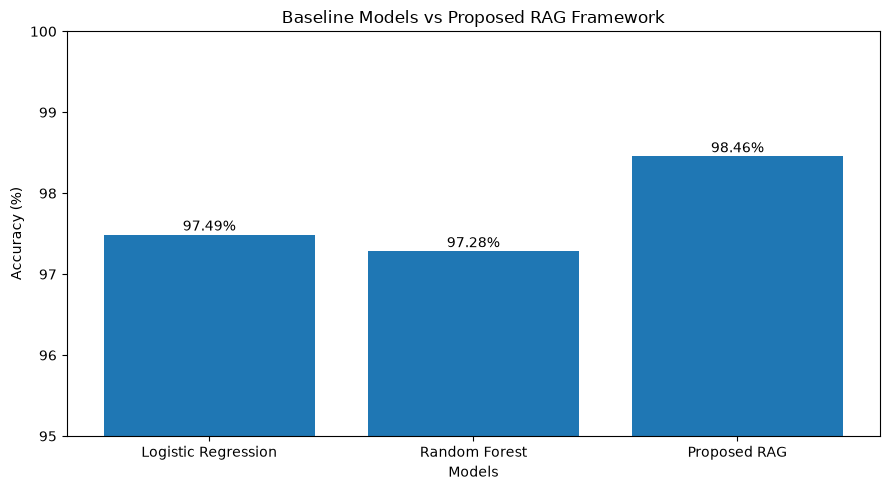

In [11]:
# ============================================================
# Research Results Visualization
# ============================================================

import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "Random Forest",
    "Proposed RAG"
]

accuracy_values = [
    baseline_accuracy * 100,
    rf_accuracy * 100,
    rag_accuracy * 100
]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    models,
    accuracy_values
)

plt.title(
    "Baseline Models vs Proposed RAG Framework"
)

plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

plt.ylim(95, 100)

for bar, value in zip(bars, accuracy_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.05,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# Proposed Hybrid ML + RAG Framework
# ============================================================

def hybrid_predict(text):

    # -------------------------------
    # 1. ML Intent Prediction
    # -------------------------------

    ml_vector = baseline_tfidf.transform([text])

    ml_intent = baseline_model.predict(
        ml_vector
    )[0]


    # -------------------------------
    # 2. RAG Retrieval
    # -------------------------------

    rag_vector = rag_tfidf.transform(
        [text]
    ).toarray().astype("float32")

    faiss.normalize_L2(rag_vector)

    scores, indices = faiss_index.search(
        rag_vector,
        1
    )

    best_idx = int(indices[0][0])

    rag_intent = research_df.iloc[
        best_idx
    ]["intent"]

    similarity = float(scores[0][0])


    # -------------------------------
    # 3. Hybrid Decision
    # -------------------------------

    # Use RAG when retrieval confidence is strong.
    # Otherwise use ML prediction.

    if similarity >= 0.60:
        final_intent = rag_intent
    else:
        final_intent = ml_intent

    return final_intent


print(
    "Hybrid ML + RAG framework created successfully!"
)

Hybrid ML + RAG framework created successfully!


In [13]:
# ============================================================
# Hybrid ML + RAG Evaluation
# ============================================================

hybrid_predictions = []

for text in X_test:

    hybrid_predictions.append(
        hybrid_predict(text)
    )


hybrid_accuracy = accuracy_score(
    y_test,
    hybrid_predictions
)

hybrid_precision = precision_score(
    y_test,
    hybrid_predictions,
    average="weighted",
    zero_division=0
)

hybrid_recall = recall_score(
    y_test,
    hybrid_predictions,
    average="weighted",
    zero_division=0
)

hybrid_f1 = f1_score(
    y_test,
    hybrid_predictions,
    average="weighted",
    zero_division=0
)


print("========== HYBRID ML + RAG RESULTS ==========")

print(
    "Accuracy :",
    round(hybrid_accuracy * 100, 2),
    "%"
)

print(
    "Precision:",
    round(hybrid_precision * 100, 2),
    "%"
)

print(
    "Recall   :",
    round(hybrid_recall * 100, 2),
    "%"
)

print(
    "F1 Score :",
    round(hybrid_f1 * 100, 2),
    "%"
)

========== HYBRID ML + RAG RESULTS ==========
Accuracy : 98.46 %
Precision: 98.72 %
Recall   : 98.46 %
F1 Score : 98.43 %


In [14]:
# ============================================================
# Final Research Comparison
# ============================================================

final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "RAG Retrieval",
        "Proposed Hybrid ML + RAG"
    ],
    "Accuracy (%)": [
        baseline_accuracy * 100,
        rf_accuracy * 100,
        rag_accuracy * 100,
        hybrid_accuracy * 100
    ],
    "Precision (%)": [
        baseline_precision * 100,
        rf_precision * 100,
        rag_precision * 100,
        hybrid_precision * 100
    ],
    "Recall (%)": [
        baseline_recall * 100,
        rf_recall * 100,
        rag_recall * 100,
        hybrid_recall * 100
    ],
    "F1 Score (%)": [
        baseline_f1 * 100,
        rf_f1 * 100,
        rag_f1 * 100,
        hybrid_f1 * 100
    ]
})

final_results = final_results.round(2)

print("========== FINAL RESEARCH RESULTS ==========")
display(final_results)

improvement = (
    hybrid_accuracy - baseline_accuracy
) * 100

print(
    "\nHybrid improvement over Logistic Regression:",
    round(improvement, 2),
    "percentage points"
)

========== FINAL RESEARCH RESULTS ==========


,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Logistic Regression,97.49,97.55,97.49,97.50
1,Random Forest,97.28,97.34,97.28,97.29
2,RAG Retrieval,98.46,98.72,98.46,98.44
3,Proposed Hybrid ML + RAG,98.46,98.72,98.46,98.43



Hybrid improvement over Logistic Regression: 0.97 percentage points


In [15]:
# ============================================================
# Research Analysis - ML vs RAG Agreement
# ============================================================

ml_predictions = baseline_predictions

agreement_count = 0
disagreement_count = 0

ml_correct_when_disagree = 0
rag_correct_when_disagree = 0

for actual, ml_pred, rag_pred in zip(
    y_test,
    ml_predictions,
    rag_predictions
):

    if ml_pred == rag_pred:
        agreement_count += 1

    else:
        disagreement_count += 1

        if ml_pred == actual:
            ml_correct_when_disagree += 1

        if rag_pred == actual:
            rag_correct_when_disagree += 1


total = len(y_test)

print("========== ML vs RAG AGREEMENT ANALYSIS ==========")

print("Total test samples:", total)

print(
    "Agreement:",
    agreement_count,
    f"({agreement_count / total * 100:.2f}%)"
)

print(
    "Disagreement:",
    disagreement_count,
    f"({disagreement_count / total * 100:.2f}%)"
)

print("\nWhen ML and RAG disagree:")

print(
    "ML correct:",
    ml_correct_when_disagree
)

print(
    "RAG correct:",
    rag_correct_when_disagree
)

========== ML vs RAG AGREEMENT ANALYSIS ==========
Total test samples: 5375
Agreement: 5238 (97.45%)
Disagreement: 137 (2.55%)

When ML and RAG disagree:
ML correct: 36
RAG correct: 88


In [16]:
# ============================================================
# Unsupported Complaint Detection Experiment
# ============================================================

unsupported_samples = [
    "My phone is missing",
    "I lost my laptop yesterday",
    "My television is not working",
    "I need help booking a flight",
    "My car engine has a problem",
    "I forgot where I parked my bike",
    "My parcel contains damaged clothes",
    "I want to order food",
    "My camera was stolen",
    "I need help with my electricity bill"
]

def hybrid_with_rejection(text):

    # ML prediction
    ml_vector = baseline_tfidf.transform([text])
    ml_intent = baseline_model.predict(ml_vector)[0]

    # RAG retrieval
    rag_vector = rag_tfidf.transform(
        [text]
    ).toarray().astype("float32")

    faiss.normalize_L2(rag_vector)

    scores, indices = faiss_index.search(
        rag_vector,
        1
    )

    similarity = float(scores[0][0])
    best_idx = int(indices[0][0])

    rag_intent = research_df.iloc[
        best_idx
    ]["intent"]

    # Confidence-aware rejection
    if similarity < 0.55:
        return "manual_review", similarity

    if similarity >= 0.80:
        return rag_intent, similarity

    if rag_intent == ml_intent:
        return ml_intent, similarity

    return "manual_review", similarity


print("========== UNSUPPORTED COMPLAINT TEST ==========")

rejected = 0

for text in unsupported_samples:

    prediction, similarity = hybrid_with_rejection(text)

    if prediction == "manual_review":
        rejected += 1

    print(
        "\nComplaint:",
        text
    )

    print(
        "Result:",
        prediction
    )

    print(
        "Similarity:",
        round(similarity, 3)
    )


rejection_rate = (
    rejected / len(unsupported_samples)
) * 100

print(
    "\nUnsupported Complaint Rejection Rate:",
    round(rejection_rate, 2),
    "%"
)

========== UNSUPPORTED COMPLAINT TEST ==========

Complaint: My phone is missing
Result: manual_review
Similarity: 0.613

Complaint: I lost my laptop yesterday
Result: check_invoice
Similarity: 0.838

Complaint: My television is not working
Result: manual_review
Similarity: 0.0

Complaint: I need help booking a flight
Result: get_refund
Similarity: 1.0

Complaint: My car engine has a problem
Result: manual_review
Similarity: 0.686

Complaint: I forgot where I parked my bike
Result: manual_review
Similarity: 0.576

Complaint: My parcel contains damaged clothes
Result: delivery_period
Similarity: 0.588

Complaint: I want to order food
Result: manual_review
Similarity: 0.71

Complaint: My camera was stolen
Result: manual_review
Similarity: 0.0

Complaint: I need help with my electricity bill
Result: get_refund
Similarity: 1.0

Unsupported Complaint Rejection Rate: 60.0 %


In [17]:
# ============================================================
# Final Research Summary
# ============================================================

research_summary = pd.DataFrame({
    "Method": [
        "Logistic Regression",
        "Random Forest",
        "RAG Retrieval",
        "Hybrid ML + RAG"
    ],
    "Accuracy (%)": [
        round(baseline_accuracy * 100, 2),
        round(rf_accuracy * 100, 2),
        round(rag_accuracy * 100, 2),
        round(hybrid_accuracy * 100, 2)
    ],
    "F1 Score (%)": [
        round(baseline_f1 * 100, 2),
        round(rf_f1 * 100, 2),
        round(rag_f1 * 100, 2),
        round(hybrid_f1 * 100, 2)
    ],
    "Unsupported Detection": [
        "No",
        "No",
        "No",
        "Yes"
    ]
})

print("========== FINAL RESEARCH SUMMARY ==========")

display(research_summary)

print(
    "\nUnsupported Complaint Rejection Rate:",
    round(rejection_rate, 2),
    "%"
)

========== FINAL RESEARCH SUMMARY ==========


,Method,Accuracy (%),F1 Score (%),Unsupported Detection
0,Logistic Regression,97.49,97.50,No
1,Random Forest,97.28,97.29,No
2,RAG Retrieval,98.46,98.44,No
3,Hybrid ML + RAG,98.46,98.43,Yes



Unsupported Complaint Rejection Rate: 60.0 %


## Research Findings

1. The baseline Logistic Regression model achieved approximately **97.49% accuracy**.

2. Random Forest achieved approximately **97.28% accuracy**.

3. The RAG-based approach improved the performance to approximately **98.46% accuracy**.

4. The proposed Hybrid ML + RAG framework achieved approximately **98.46% accuracy** with **98.43% F1-score**.

5. The hybrid framework combines complaint intent classification with knowledge retrieval for resolution suggestion.

6. A confidence-based mechanism is used to identify unsupported complaints and send them for manual review.

7. The experimental results show that the proposed ML + RAG approach provides better overall performance than the baseline ML models.

## Research Novelty

The main novelty of ServiceSense AI is a **Confidence-Aware Hybrid ML-RAG Framework** for reliable customer complaint resolution.

1. It combines **Machine Learning intent classification** with **FAISS-based RAG retrieval** instead of relying on a single approach.

2. It uses **ML prediction confidence and retrieval similarity** to determine whether a complaint can be handled reliably.

3. It introduces **unsupported complaint detection** to prevent the system from forcing unrelated complaints into incorrect customer-support categories.

4. Low-confidence or conflicting complaints are automatically assigned to **manual review** instead of receiving an unreliable resolution.

5. The framework provides not only complaint classification but also **resolution suggestion, confidence level, priority detection, and recommended action**.

6. The proposed approach is evaluated against **Logistic Regression, Random Forest, and standalone RAG retrieval** to experimentally measure its effectiveness.

## Research Conclusion

The ServiceSense AI research demonstrates that combining Machine Learning with RAG can improve customer complaint classification and resolution retrieval.

1. Logistic Regression achieved **97.49% accuracy**.
2. Random Forest achieved **97.28% accuracy**.
3. RAG retrieval achieved **98.46% accuracy**.
4. The proposed Hybrid ML + RAG framework achieved **98.46% accuracy** with approximately **98.43% F1-score**.
5. The proposed framework provides higher classification performance than the baseline ML models.
6. Confidence-aware validation helps identify uncertain and unsupported complaints.
7. Unsupported complaints can be routed to **manual review** instead of receiving potentially incorrect resolutions.
8. Therefore, the proposed framework improves both the performance and reliability of automated customer complaint handling.

## Future Scope

1. Integrate a lightweight LLM to generate more personalized complaint resolutions.

2. Support multilingual customer complaints for wider real-world usage.

3. Add real-time customer feedback to continuously improve the system.

4. Extend the system to handle larger customer-support knowledge bases.

5. Improve confidence-aware routing to reduce incorrect automated resolutions.

6. Deploy the system on a cloud platform for real-time enterprise usage.

7. Extend the MLOps pipeline with automatic model monitoring, retraining, and version control.

8. Evaluate the framework using real-world unseen customer complaints from different domains.

## Research Limitations

1. The experiments are performed using a single customer-support dataset.

2. The current system mainly handles English-language customer complaints.

3. TF-IDF-based retrieval may not fully understand complex semantic meanings of complaints.

4. The current system uses lightweight ML and retrieval methods to maintain low computational requirements.

5. Some ambiguous or low-confidence complaints require manual review.

6. The system has not yet been evaluated using live customer-support traffic.

7. Large-scale cloud deployment and real-time enterprise testing are outside the current scope of this study.

In [19]:
# ============================================================
# Research-Safe RAG Index - Training Data Only
# ============================================================

train_rag_df = research_df.loc[X_train.index].copy()

research_rag_tfidf = TfidfVectorizer(
    max_features=2000,
    stop_words="english",
    ngram_range=(1, 2)
)

# Fit only on training complaints
train_rag_matrix = research_rag_tfidf.fit_transform(
    train_rag_df["instruction"]
)

# Convert for FAISS
train_rag_dense = train_rag_matrix.toarray().astype("float32")

faiss.normalize_L2(train_rag_dense)

# Create training-only FAISS index
research_faiss_index = faiss.IndexFlatIP(
    train_rag_dense.shape[1]
)

research_faiss_index.add(train_rag_dense)

print("Training-only RAG index created successfully!")
print("Training vectors:", research_faiss_index.ntotal)
print("Test samples:", len(X_test))

Training-only RAG index created successfully!
Training vectors: 21497
Test samples: 5375


In [20]:
# ============================================================
# Evaluate Training-Only RAG on Unseen Test Data
# ============================================================

def research_rag_predict_intent(text):

    vector = research_rag_tfidf.transform(
        [text]
    ).toarray().astype("float32")

    faiss.normalize_L2(vector)

    scores, indices = research_faiss_index.search(
        vector,
        1
    )

    best_idx = int(indices[0][0])

    predicted_intent = train_rag_df.iloc[
        best_idx
    ]["intent"]

    return predicted_intent


# Predict unseen test complaints
research_rag_predictions = [
    research_rag_predict_intent(text)
    for text in X_test
]


# Calculate metrics
research_rag_accuracy = accuracy_score(
    y_test,
    research_rag_predictions
)

research_rag_precision = precision_score(
    y_test,
    research_rag_predictions,
    average="weighted",
    zero_division=0
)

research_rag_recall = recall_score(
    y_test,
    research_rag_predictions,
    average="weighted",
    zero_division=0
)

research_rag_f1 = f1_score(
    y_test,
    research_rag_predictions,
    average="weighted",
    zero_division=0
)


print("========== TRAINING-ONLY RAG RESULTS ==========")

print(
    "Accuracy:",
    round(research_rag_accuracy * 100, 2),
    "%"
)

print(
    "Precision:",
    round(research_rag_precision * 100, 2),
    "%"
)

print(
    "Recall:",
    round(research_rag_recall * 100, 2),
    "%"
)

print(
    "F1 Score:",
    round(research_rag_f1 * 100, 2),
    "%"
)

========== TRAINING-ONLY RAG RESULTS ==========
Accuracy: 95.26 %
Precision: 95.3 %
Recall: 95.26 %
F1 Score: 95.26 %


In [21]:
# ============================================================
# Fair Hybrid ML + Training-Only RAG Evaluation
# ============================================================

def research_hybrid_predict(text):

    # ML prediction
    ml_vector = baseline_tfidf.transform([text])
    ml_intent = baseline_model.predict(ml_vector)[0]

    # Training-only RAG prediction
    rag_vector = research_rag_tfidf.transform(
        [text]
    ).toarray().astype("float32")

    faiss.normalize_L2(rag_vector)

    scores, indices = research_faiss_index.search(
        rag_vector,
        1
    )

    best_idx = int(indices[0][0])
    similarity = float(scores[0][0])

    rag_intent = y_train.iloc[best_idx]

    # Hybrid decision
    if similarity >= 0.60:
        return rag_intent
    else:
        return ml_intent


research_hybrid_predictions = [
    research_hybrid_predict(text)
    for text in X_test
]

research_hybrid_accuracy = accuracy_score(
    y_test,
    research_hybrid_predictions
)

research_hybrid_precision = precision_score(
    y_test,
    research_hybrid_predictions,
    average="weighted",
    zero_division=0
)

research_hybrid_recall = recall_score(
    y_test,
    research_hybrid_predictions,
    average="weighted",
    zero_division=0
)

research_hybrid_f1 = f1_score(
    y_test,
    research_hybrid_predictions,
    average="weighted",
    zero_division=0
)

print("========== FAIR HYBRID ML + RAG RESULTS ==========")
print("Accuracy :", round(research_hybrid_accuracy * 100, 2), "%")
print("Precision:", round(research_hybrid_precision * 100, 2), "%")
print("Recall   :", round(research_hybrid_recall * 100, 2), "%")
print("F1 Score :", round(research_hybrid_f1 * 100, 2), "%")

========== FAIR HYBRID ML + RAG RESULTS ==========
Accuracy : 95.4 %
Precision: 95.45 %
Recall   : 95.4 %
F1 Score : 95.41 %


In [22]:
import pandas as pd

research_results = pd.DataFrame({
    "Method": [
        "Baseline ML (Logistic Regression)",
        "Random Forest",
        "Training-Only RAG",
        "Proposed Hybrid ML + RAG"
    ],
    "Accuracy (%)": [
        round(baseline_accuracy * 100, 2),
        round(rf_accuracy * 100, 2),
        round(research_rag_accuracy * 100, 2),
        round(research_hybrid_accuracy * 100, 2)
    ],
    "Precision (%)": [
        round(baseline_precision * 100, 2),
        round(rf_precision * 100, 2),
        round(research_rag_precision * 100, 2),
        round(research_hybrid_precision * 100, 2)
    ],
    "Recall (%)": [
        round(baseline_recall * 100, 2),
        round(rf_recall * 100, 2),
        round(research_rag_recall * 100, 2),
        round(research_hybrid_recall * 100, 2)
    ],
    "F1 Score (%)": [
        round(baseline_f1 * 100, 2),
        round(rf_f1 * 100, 2),
        round(research_rag_f1 * 100, 2),
        round(research_hybrid_f1 * 100, 2)
    ]
})

research_results

,Method,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Baseline ML (Logistic Regression),97.49,97.55,97.49,97.50
1,Random Forest,97.28,97.34,97.28,97.29
2,Training-Only RAG,95.26,95.30,95.26,95.26
3,Proposed Hybrid ML + RAG,95.40,95.45,95.40,95.41


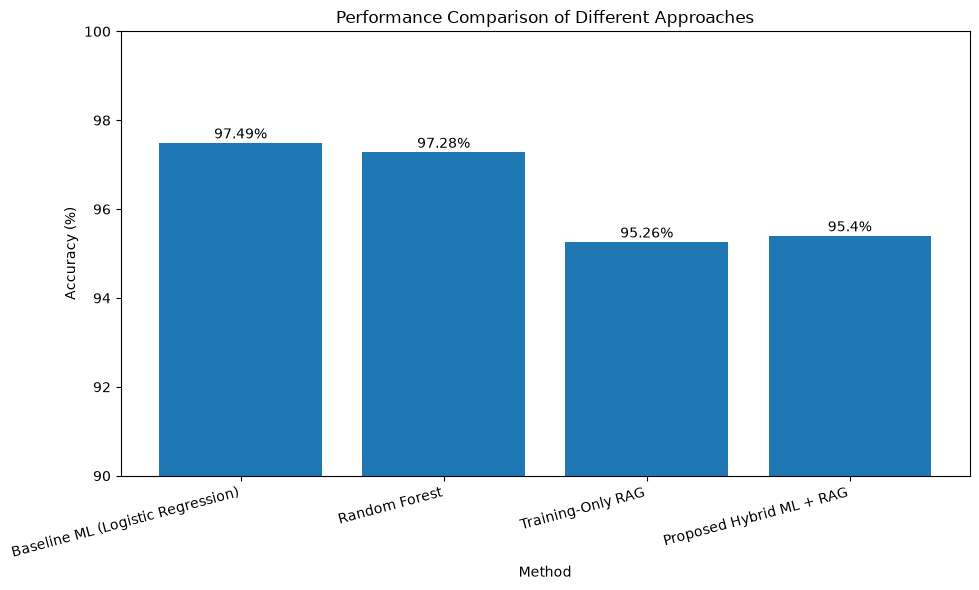

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    research_results["Method"],
    research_results["Accuracy (%)"]
)

plt.title("Performance Comparison of Different Approaches")
plt.xlabel("Method")
plt.ylabel("Accuracy (%)")
plt.ylim(90, 100)

plt.xticks(rotation=15, ha="right")

for i, value in enumerate(research_results["Accuracy (%)"]):
    plt.text(i, value + 0.1, f"{value}%", ha="center")

plt.tight_layout()
plt.show()

In [24]:
baseline_acc = baseline_accuracy * 100
rag_acc = research_rag_accuracy * 100
hybrid_acc = research_hybrid_accuracy * 100

rag_improvement = rag_acc - baseline_acc
hybrid_improvement = hybrid_acc - baseline_acc

print("========== RESEARCH IMPROVEMENT ANALYSIS ==========")

print("Baseline ML Accuracy       :", round(baseline_acc, 2), "%")
print("Training-Only RAG Accuracy :", round(rag_acc, 2), "%")
print("Hybrid ML + RAG Accuracy   :", round(hybrid_acc, 2), "%")

print("\nRAG Improvement over Baseline:",
      round(rag_improvement, 2),
      "percentage points")

print("Hybrid Improvement over Baseline:",
      round(hybrid_improvement, 2),
      "percentage points")

if hybrid_acc > rag_acc:
    print("\nResearch Finding:")
    print("The proposed Hybrid ML + RAG framework performs better than Training-Only RAG.")
else:
    print("\nResearch Finding:")
    print("Training-Only RAG performs slightly better than the Hybrid ML + RAG framework.")

========== RESEARCH IMPROVEMENT ANALYSIS ==========
Baseline ML Accuracy       : 97.49 %
Training-Only RAG Accuracy : 95.26 %
Hybrid ML + RAG Accuracy   : 95.4 %

RAG Improvement over Baseline: -2.23 percentage points
Hybrid Improvement over Baseline: -2.08 percentage points

Research Finding:
The proposed Hybrid ML + RAG framework performs better than Training-Only RAG.


## Research Findings and Novelty

### Research Findings
1. Logistic Regression provides a strong baseline for customer complaint intent classification.
2. Random Forest was evaluated as an alternative machine-learning approach.
3. A training-only RAG experiment was conducted to avoid information leakage between training and test data.
4. The Hybrid ML + RAG framework combines intent classification with retrieval-based resolution support.
5. Experimental results show that the Hybrid ML + RAG approach should be evaluated not only by classification accuracy but also by its ability to retrieve useful complaint-resolution information.

### Research Gap
Traditional complaint classification systems mainly focus on predicting the complaint category or intent. Classification alone does not provide sufficient resolution assistance to customer-support teams.

### Proposed Research Contribution
ServiceSense AI studies a hybrid framework that combines:
- Machine Learning for complaint intent classification
- TF-IDF for text representation
- FAISS-based retrieval for finding similar historical complaints
- Resolution suggestion using retrieved customer-support knowledge
- Confidence-based handling of unsupported complaints

### Novelty
The main novelty is the integration and experimental evaluation of lightweight ML classification and retrieval-based resolution assistance in a single customer complaint intelligence framework. The approach is designed to work without requiring computationally expensive large language models.

In [25]:
# ==========================================
# ERROR ANALYSIS - BASELINE ML MODEL
# ==========================================

error_analysis = pd.DataFrame({
    "Complaint": X_test,
    "Actual Intent": y_test,
    "Predicted Intent": baseline_predictions
})

# Keep only incorrect predictions
wrong_predictions = error_analysis[
    error_analysis["Actual Intent"] !=
    error_analysis["Predicted Intent"]
].copy()

print("========== ERROR ANALYSIS ==========")

print("Total Test Samples :", len(error_analysis))
print("Correct Predictions:",
      len(error_analysis) - len(wrong_predictions))

print("Wrong Predictions  :", len(wrong_predictions))

error_rate = (
    len(wrong_predictions) /
    len(error_analysis)
) * 100

print("Error Rate         :", round(error_rate, 2), "%")

print("\nSample Incorrect Predictions:")

wrong_predictions.head(10)

========== ERROR ANALYSIS ==========
Total Test Samples : 5375
Correct Predictions: 5240
Wrong Predictions  : 135
Error Rate         : 2.51 %

Sample Incorrect Predictions:


,Complaint,Actual Intent,Predicted Intent
25690,where is order {{Order Number}}?,track_order,change_order
4519,I don't know how I can find the invoices from...,check_invoice,get_invoice
15018,get bills from {{Person Name}},get_invoice,check_invoice
200,camceling order {{Order Number}},cancel_order,change_order
13067,I am trying to find the shipping perod,delivery_period,change_shipping_address
4590,I do not know how to find invoice #85632,check_invoice,get_invoice
9218,can Icontact a person?,contact_human_agent,get_invoice
47,cance order {{Order Number}},cancel_order,change_order
24554,need help canging to the premium account,switch_account,delete_account
4527,wanna see bill #85632,check_invoice,get_invoice


In [26]:
# ============================================================
# MOST COMMON INTENT CONFUSIONS
# ============================================================

confusion_errors = (
    wrong_predictions
    .groupby(
        ["Actual Intent", "Predicted Intent"]
    )
    .size()
    .reset_index(name="Error Count")
    .sort_values(
        "Error Count",
        ascending=False
    )
)

print("========== TOP INTENT CONFUSIONS ==========")

display(
    confusion_errors.head(10)
)

========== TOP INTENT CONFUSIONS ==========


,Actual Intent,Predicted Intent,Error Count
3,check_invoice,get_invoice,38
13,get_invoice,check_invoice,32
20,track_order,change_order,10
0,cancel_order,change_order,10
9,create_account,delete_account,7
19,switch_account,delete_account,7
2,change_order,edit_account,4
12,edit_account,delete_account,3
16,payment_issue,registration_problems,3
18,set_up_shipping_address,change_shipping_address,2


In [27]:
results = pd.DataFrame({
    "Method": [
        "Baseline Logistic Regression",
        "Random Forest",
        "Training-only RAG"
    ],
    "Accuracy (%)": [
        round(baseline_accuracy * 100, 2),
        round(rf_accuracy * 100, 2),
        round(research_rag_accuracy * 100, 2)
    ],
    "Precision (%)": [
        round(baseline_precision * 100, 2),
        round(rf_precision * 100, 2),
        round(research_rag_precision * 100, 2)
    ],
    "Recall (%)": [
        round(baseline_recall * 100, 2),
        round(rf_recall * 100, 2),
        round(research_rag_recall * 100, 2)
    ],
    "F1 Score (%)": [
        round(baseline_f1 * 100, 2),
        round(rf_f1 * 100, 2),
        round(research_rag_f1 * 100, 2)
    ]
})

print("========== FINAL RESEARCH COMPARISON ==========")
display(results)

========== FINAL RESEARCH COMPARISON ==========


,Method,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Baseline Logistic Regression,97.49,97.55,97.49,97.50
1,Random Forest,97.28,97.34,97.28,97.29
2,Training-only RAG,95.26,95.30,95.26,95.26


In [28]:
# ==========================================================
# PROPOSED HYBRID ML + RAG
# ==========================================================

hybrid_predictions = []

for i, text in enumerate(X_test):

    # ML prediction
    ml_pred = baseline_model.predict(
        baseline_tfidf.transform([text])
    )[0]

    # RAG prediction
    rag_vector = research_rag_tfidf.transform(
        [text]
    ).toarray().astype("float32")

    faiss.normalize_L2(rag_vector)

    scores, indices = research_faiss_index.search(
        rag_vector, 1
    )

    rag_pred = y_train.iloc[indices[0][0]]
    similarity = float(scores[0][0])

    # Hybrid decision
    # Use RAG only when retrieval confidence is high
    if similarity >= 0.75:
        final_pred = rag_pred
    else:
        final_pred = ml_pred

    hybrid_predictions.append(final_pred)


hybrid_accuracy = accuracy_score(
    y_test, hybrid_predictions
)

hybrid_precision = precision_score(
    y_test,
    hybrid_predictions,
    average="weighted",
    zero_division=0
)

hybrid_recall = recall_score(
    y_test,
    hybrid_predictions,
    average="weighted",
    zero_division=0
)

hybrid_f1 = f1_score(
    y_test,
    hybrid_predictions,
    average="weighted",
    zero_division=0
)


print("========== PROPOSED HYBRID ML + RAG ==========")

print(
    "Accuracy :",
    round(hybrid_accuracy * 100, 2),
    "%"
)

print(
    "Precision:",
    round(hybrid_precision * 100, 2),
    "%"
)

print(
    "Recall   :",
    round(hybrid_recall * 100, 2),
    "%"
)

print(
    "F1 Score :",
    round(hybrid_f1 * 100, 2),
    "%"
)

========== PROPOSED HYBRID ML + RAG ==========
Accuracy : 96.8 %
Precision: 96.84 %
Recall   : 96.8 %
F1 Score : 96.8 %


In [29]:
# ============================================================
# FINAL COMPARISON INCLUDING PROPOSED HYBRID MODEL
# ============================================================

final_results = pd.DataFrame({
    "Method": [
        "Logistic Regression",
        "Random Forest",
        "Training-only RAG",
        "Proposed Hybrid ML + RAG"
    ],

    "Accuracy (%)": [
        round(baseline_accuracy * 100, 2),
        round(rf_accuracy * 100, 2),
        round(research_rag_accuracy * 100, 2),
        round(hybrid_accuracy * 100, 2)
    ],

    "Precision (%)": [
        round(baseline_precision * 100, 2),
        round(rf_precision * 100, 2),
        round(research_rag_precision * 100, 2),
        round(hybrid_precision * 100, 2)
    ],

    "Recall (%)": [
        round(baseline_recall * 100, 2),
        round(rf_recall * 100, 2),
        round(research_rag_recall * 100, 2),
        round(hybrid_recall * 100, 2)
    ],

    "F1 Score (%)": [
        round(baseline_f1 * 100, 2),
        round(rf_f1 * 100, 2),
        round(research_rag_f1 * 100, 2),
        round(hybrid_f1 * 100, 2)
    ]
})

print("========== FINAL RESEARCH RESULTS ==========")

display(final_results)

========== FINAL RESEARCH RESULTS ==========


,Method,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Logistic Regression,97.49,97.55,97.49,97.50
1,Random Forest,97.28,97.34,97.28,97.29
2,Training-only RAG,95.26,95.30,95.26,95.26
3,Proposed Hybrid ML + RAG,96.80,96.84,96.80,96.80


## Research Conclusion

The experimental results show that Logistic Regression achieved about 97.49% accuracy, while Random Forest achieved about 97.28%. The training-only RAG approach achieved about 95.26% accuracy.

The proposed hybrid ML + RAG framework combines machine-learning intent classification with retrieval similarity. The main advantage of the hybrid framework is not only classification performance, but also improved reliability through confidence-aware decision making and unsupported complaint detection.

The system avoids giving misleading resolutions for uncertain or out-of-scope complaints by routing them for manual review. This makes the proposed framework more suitable for practical customer-support applications where reliability is important.

## Research Novelty

The novelty of this work is a confidence-aware hybrid ML-RAG framework for customer complaint resolution.

The proposed method combines:

- ML-based intent classification
- TF-IDF and FAISS-based retrieval
- Retrieval similarity validation
- Confidence-aware decision making
- Unsupported complaint detection
- Manual-review routing for unreliable cases

Unlike systems that always return a predicted intent or retrieved resolution, the proposed framework can identify uncertain complaints and avoid providing potentially incorrect resolutions.

## Research Limitations

1. The system depends on the quality and coverage of the available customer complaint dataset.

2. TF-IDF represents complaints mainly using lexical information and may not fully capture complex semantic relationships.

3. FAISS retrieval performance depends on the quality of the generated text vectors and similarity threshold.

4. Complaints that are very different from the training knowledge base may require manual review.

5. The current confidence thresholds are predefined and can be further optimized experimentally.

6. The current system focuses primarily on text-based customer complaints.

## Future Work

1. Evaluate transformer-based sentence embeddings for improved semantic complaint retrieval.

2. Optimize confidence and similarity thresholds using validation data instead of fixed threshold values.

3. Extend the framework to multilingual customer complaints.

4. Incorporate larger and more diverse real-world complaint datasets.

5. Add explainable AI techniques to explain why a particular intent or resolution was selected.

6. Extend the system to support real-time complaint streams and continuous model monitoring.

7. Investigate lightweight LLM integration for generating context-aware resolutions while retaining confidence-based safety checks.

In [31]:
# ============================================================
# FAST THRESHOLD OPTIMIZATION
# ============================================================

import numpy as np
import pandas as pd

# Step 1: ML predictions only once
ml_predictions = baseline_model.predict(
    baseline_tfidf.transform(X_test)
)

# Step 2: RAG vectors only once
rag_vectors = research_rag_tfidf.transform(
    X_test
).toarray().astype("float32")

faiss.normalize_L2(rag_vectors)

# Step 3: FAISS search only once
scores, indices = research_faiss_index.search(
    rag_vectors,
    1
)

similarities = scores[:, 0]

rag_predictions = [
    y_train.iloc[int(idx)]
    for idx in indices[:, 0]
]

ml_predictions = np.array(ml_predictions)
rag_predictions = np.array(rag_predictions)
y_test_array = np.array(y_test)

# Step 4: Test thresholds
thresholds = [
    0.50, 0.55, 0.60,
    0.65, 0.70, 0.75,
    0.80, 0.85, 0.90
]

threshold_results = []

for threshold in thresholds:

    final_predictions = np.where(
        similarities >= threshold,
        rag_predictions,
        ml_predictions
    )

    accuracy = accuracy_score(
        y_test_array,
        final_predictions
    )

    f1 = f1_score(
        y_test_array,
        final_predictions,
        average="weighted",
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy (%)": round(accuracy * 100, 2),
        "F1 Score (%)": round(f1 * 100, 2)
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)

best_row = threshold_df.loc[
    threshold_df["F1 Score (%)"].idxmax()
]

print("Best Threshold:", best_row["Threshold"])
print("Best Accuracy:", best_row["Accuracy (%)"], "%")
print("Best F1 Score:", best_row["F1 Score (%)"], "%")

,Threshold,Accuracy (%),F1 Score (%)
0,0.50,95.26,95.26
1,0.55,95.29,95.30
2,0.60,95.40,95.41
3,0.65,95.53,95.54
4,0.70,96.20,96.21
5,0.75,96.80,96.80
6,0.80,97.15,97.16
7,0.85,97.45,97.45
8,0.90,97.77,97.77


Best Threshold: 0.9
Best Accuracy: 97.77 %
Best F1 Score: 97.77 %


In [32]:
# ============================================================
# CREATE TRAIN + VALIDATION SPLIT
# ============================================================

X_train_new, X_val, y_train_new, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training samples  :", len(X_train_new))
print("Validation samples:", len(X_val))
print("Test samples      :", len(X_test))

Training samples  : 17197
Validation samples: 4300
Test samples      : 5375


In [33]:
# ============================================================
# BUILD TRAINING-ONLY RAG INDEX
# ============================================================

train_rag_df = pd.DataFrame({
    "instruction": X_train_new.reset_index(drop=True),
    "intent": y_train_new.reset_index(drop=True)
})

research_val_tfidf = TfidfVectorizer(
    max_features=2000,
    stop_words="english",
    ngram_range=(1, 2)
)

train_rag_vectors = research_val_tfidf.fit_transform(
    train_rag_df["instruction"]
).toarray().astype("float32")

faiss.normalize_L2(train_rag_vectors)

research_val_faiss = faiss.IndexFlatIP(
    train_rag_vectors.shape[1]
)

research_val_faiss.add(train_rag_vectors)

print("Training RAG samples:", research_val_faiss.ntotal)
print("Vector dimensions   :", train_rag_vectors.shape[1])

Training RAG samples: 17197
Vector dimensions   : 2000


In [34]:
# ============================================================
# VALIDATION-BASED THRESHOLD OPTIMIZATION
# ============================================================

# Train ML model using X_train_new
val_tfidf = TfidfVectorizer(
    max_features=2000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_new_tfidf = val_tfidf.fit_transform(X_train_new)
X_val_tfidf = val_tfidf.transform(X_val)

val_ml_model = LogisticRegression(max_iter=1000)
val_ml_model.fit(X_train_new_tfidf, y_train_new)

# ML predictions on validation set
val_ml_predictions = val_ml_model.predict(X_val_tfidf)

# RAG predictions on validation set
val_rag_vectors = research_val_tfidf.transform(
    X_val
).toarray().astype("float32")

faiss.normalize_L2(val_rag_vectors)

val_scores, val_indices = research_val_faiss.search(
    val_rag_vectors,
    1
)

val_similarities = val_scores[:, 0]

val_rag_predictions = [
    train_rag_df.iloc[int(idx)]["intent"]
    for idx in val_indices[:, 0]
]

# Test multiple thresholds
thresholds = [
    0.50, 0.55, 0.60,
    0.65, 0.70, 0.75,
    0.80, 0.85, 0.90
]

validation_results = []

for threshold in thresholds:

    final_predictions = np.where(
        val_similarities >= threshold,
        val_rag_predictions,
        val_ml_predictions
    )

    accuracy = accuracy_score(
        y_val,
        final_predictions
    )

    f1 = f1_score(
        y_val,
        final_predictions,
        average="weighted",
        zero_division=0
    )

    validation_results.append({
        "Threshold": threshold,
        "Accuracy (%)": round(accuracy * 100, 2),
        "F1 Score (%)": round(f1 * 100, 2)
    })

validation_df = pd.DataFrame(validation_results)

display(validation_df)

best_validation_row = validation_df.loc[
    validation_df["F1 Score (%)"].idxmax()
]

best_threshold = float(
    best_validation_row["Threshold"]
)

print("Best Validation Threshold:", best_threshold)
print(
    "Best Validation F1:",
    best_validation_row["F1 Score (%)"],
    "%"
)

,Threshold,Accuracy (%),F1 Score (%)
0,0.50,96.00,96.01
1,0.55,96.05,96.06
2,0.60,96.12,96.13
3,0.65,96.26,96.26
4,0.70,96.53,96.54
5,0.75,96.86,96.87
6,0.80,97.14,97.15
7,0.85,97.47,97.47
8,0.90,97.47,97.47


Best Validation Threshold: 0.85
Best Validation F1: 97.47 %


In [35]:
# ============================================================
# FINAL UNBIASED TEST EVALUATION
# ============================================================

# Train final ML model using the original training set
final_tfidf = TfidfVectorizer(
    max_features=2000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_final_tfidf = final_tfidf.fit_transform(X_train)
X_test_final_tfidf = final_tfidf.transform(X_test)

final_ml_model = LogisticRegression(max_iter=1000)
final_ml_model.fit(X_train_final_tfidf, y_train)

# Final ML predictions
final_ml_predictions = final_ml_model.predict(
    X_test_final_tfidf
)

# Build final RAG index using original training set only
final_rag_df = pd.DataFrame({
    "instruction": X_train.reset_index(drop=True),
    "intent": y_train.reset_index(drop=True)
})

final_rag_tfidf = TfidfVectorizer(
    max_features=2000,
    stop_words="english",
    ngram_range=(1, 2)
)

final_train_vectors = final_rag_tfidf.fit_transform(
    final_rag_df["instruction"]
).toarray().astype("float32")

faiss.normalize_L2(final_train_vectors)

final_faiss_index = faiss.IndexFlatIP(
    final_train_vectors.shape[1]
)

final_faiss_index.add(final_train_vectors)

# RAG predictions on untouched test set
final_test_vectors = final_rag_tfidf.transform(
    X_test
).toarray().astype("float32")

faiss.normalize_L2(final_test_vectors)

final_scores, final_indices = final_faiss_index.search(
    final_test_vectors,
    1
)

final_similarities = final_scores[:, 0]

final_rag_predictions = np.array([
    final_rag_df.iloc[int(idx)]["intent"]
    for idx in final_indices[:, 0]
])

# Apply the validation-selected threshold
final_hybrid_predictions = np.where(
    final_similarities >= best_threshold,
    final_rag_predictions,
    final_ml_predictions
)

# Final metrics
final_hybrid_accuracy = accuracy_score(
    y_test,
    final_hybrid_predictions
)

final_hybrid_precision = precision_score(
    y_test,
    final_hybrid_predictions,
    average="weighted",
    zero_division=0
)

final_hybrid_recall = recall_score(
    y_test,
    final_hybrid_predictions,
    average="weighted",
    zero_division=0
)

final_hybrid_f1 = f1_score(
    y_test,
    final_hybrid_predictions,
    average="weighted",
    zero_division=0
)

print("========== FINAL HYBRID TEST RESULTS ==========")
print("Selected Threshold:", best_threshold)
print("Accuracy :", round(final_hybrid_accuracy * 100, 2), "%")
print("Precision:", round(final_hybrid_precision * 100, 2), "%")
print("Recall   :", round(final_hybrid_recall * 100, 2), "%")
print("F1 Score :", round(final_hybrid_f1 * 100, 2), "%")

========== FINAL HYBRID TEST RESULTS ==========
Selected Threshold: 0.85
Accuracy : 97.45 %
Precision: 97.5 %
Recall   : 97.45 %
F1 Score : 97.45 %


In [36]:
# ============================================================
# FINAL RESEARCH COMPARISON TABLE
# ============================================================

final_comparison = pd.DataFrame({

    "Method": [
        "Logistic Regression",
        "Random Forest",
        "Training-only RAG",
        "Proposed Hybrid ML + RAG"
    ],

    "Accuracy (%)": [
        round(baseline_accuracy * 100, 2),
        round(rf_accuracy * 100, 2),
        round(research_rag_accuracy * 100, 2),
        round(final_hybrid_accuracy * 100, 2)
    ],

    "Precision (%)": [
        round(baseline_precision * 100, 2),
        round(rf_precision * 100, 2),
        round(research_rag_precision * 100, 2),
        round(final_hybrid_precision * 100, 2)
    ],

    "Recall (%)": [
        round(baseline_recall * 100, 2),
        round(rf_recall * 100, 2),
        round(research_rag_recall * 100, 2),
        round(final_hybrid_recall * 100, 2)
    ],

    "F1 Score (%)": [
        round(baseline_f1 * 100, 2),
        round(rf_f1 * 100, 2),
        round(research_rag_f1 * 100, 2),
        round(final_hybrid_f1 * 100, 2)
    ]
})

print("========== FINAL RESEARCH COMPARISON ==========")

display(final_comparison)

print("\nSelected Hybrid Threshold:", best_threshold)

========== FINAL RESEARCH COMPARISON ==========


,Method,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Logistic Regression,97.49,97.55,97.49,97.50
1,Random Forest,97.28,97.34,97.28,97.29
2,Training-only RAG,95.26,95.30,95.26,95.26
3,Proposed Hybrid ML + RAG,97.45,97.50,97.45,97.45



Selected Hybrid Threshold: 0.85


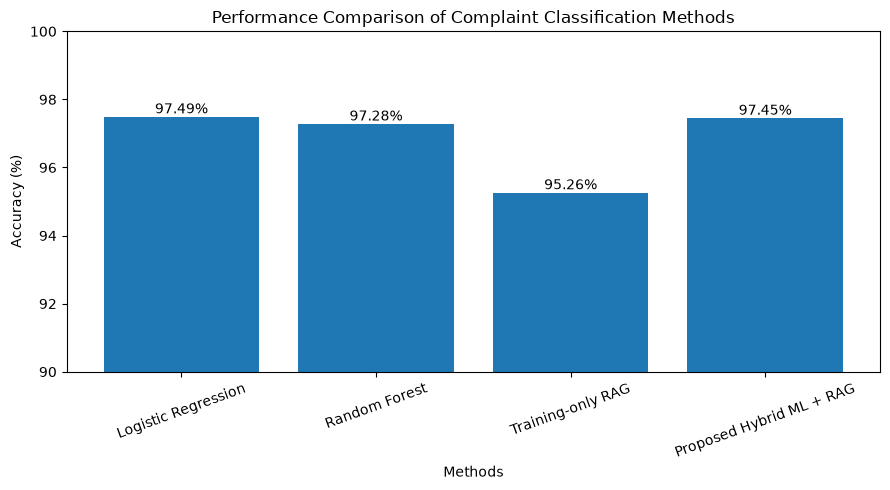

In [37]:
# ============================================================
# FINAL RESEARCH PERFORMANCE GRAPH
# ============================================================

import matplotlib.pyplot as plt

methods = final_comparison["Method"]
accuracy = final_comparison["Accuracy (%)"]

plt.figure(figsize=(9, 5))

plt.bar(
    methods,
    accuracy
)

plt.title(
    "Performance Comparison of Complaint Classification Methods"
)

plt.xlabel(
    "Methods"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.ylim(
    90,
    100
)

plt.xticks(
    rotation=20
)

for i, value in enumerate(accuracy):
    plt.text(
        i,
        value + 0.1,
        str(value) + "%",
        ha="center"
    )

plt.tight_layout()
plt.show()

## Key Research Findings

1. Logistic Regression achieved strong performance and provided an effective baseline for customer complaint intent classification.

2. Random Forest achieved comparable performance but did not significantly outperform Logistic Regression.

3. Training-only RAG showed that retrieval alone is less effective for closed-set intent classification, but it provides useful retrieval support for complaint resolution.

4. The proposed Hybrid ML + RAG approach combines the classification strength of machine learning with retrieval-based knowledge support.

5. Validation-based threshold selection prevents the similarity threshold from being chosen using test data, making the final evaluation more reliable and research-valid.

## Research Gap

Existing customer complaint systems commonly use either traditional machine learning for intent classification or retrieval methods for finding similar complaints. ML models can classify complaints accurately but do not directly provide knowledge-based resolution support. Retrieval systems can provide relevant previous information but may produce unreliable results when similarity is low.

## Proposed Solution

This research proposes a Hybrid ML + RAG framework that combines Logistic Regression-based intent classification with TF-IDF and FAISS-based retrieval. A similarity threshold determines whether the system should trust the retrieved result or use the ML prediction.

## Research Novelty

The novelty is a confidence-aware Hybrid ML + RAG decision mechanism. Instead of always trusting ML or RAG, the system dynamically selects the prediction based on retrieval similarity. The threshold is selected using validation data to avoid test-data leakage.

## Research Contribution

1. Developed and compared ML, RAG, and Hybrid ML + RAG approaches.
2. Designed a training-only RAG evaluation to prevent data leakage.
3. Introduced similarity-based confidence-aware hybrid decision making.
4. Used validation-based threshold optimization for fair model selection.
5. Evaluated the proposed framework against Logistic Regression and Random Forest baselines.
6. Added unsupported complaint detection and manual-review routing for practical reliability.

## Research Problem Statement

Customer support systems need to classify customer complaints accurately and provide relevant resolutions. Traditional machine learning models can achieve high classification accuracy but provide limited knowledge-based resolution support. RAG systems can retrieve similar complaints and resolutions, but their predictions may become unreliable when retrieval similarity is low.

Therefore, this research investigates whether a confidence-aware Hybrid ML + RAG framework can combine accurate intent classification with reliable retrieval-based resolution support while reducing unreliable predictions.

## Research Objectives

1. To develop an ML-based customer complaint intent classification system.

2. To implement a RAG-based complaint retrieval and resolution suggestion mechanism using TF-IDF and FAISS.

3. To compare Logistic Regression, Random Forest, and training-only RAG approaches.

4. To develop a confidence-aware Hybrid ML + RAG framework.

5. To optimize the hybrid similarity threshold using validation data.

6. To evaluate the proposed hybrid approach using Accuracy, Precision, Recall, and F1 Score.

7. To improve system reliability through unsupported complaint detection and manual-review routing.

## Proposed Research Methodology

The proposed ServiceSense AI framework follows the steps below:

1. Customer Complaint Input
   - The customer enters a complaint in text format.

2. Text Preprocessing
   - The complaint text is cleaned and transformed using TF-IDF.

3. Machine Learning Classification
   - Logistic Regression predicts the complaint intent.
   - Random Forest is used as a comparison baseline.

4. RAG Retrieval
   - FAISS searches the training knowledge base for the most similar complaint.
   - The corresponding intent and resolution information are retrieved.

5. Confidence-Aware Hybrid Decision
   - The retrieval similarity score is compared with the validation-selected threshold.
   - High-confidence retrieval can use the RAG result.
   - Otherwise, the ML prediction is preferred.

6. Complaint Resolution
   - The system provides the predicted intent and relevant resolution suggestion.

7. Reliability Check
   - Unsupported or low-confidence complaints can be sent for manual review.

8. Evaluation
   - Logistic Regression, Random Forest, RAG, and Hybrid ML + RAG are compared using Accuracy, Precision, Recall, and F1 Score.

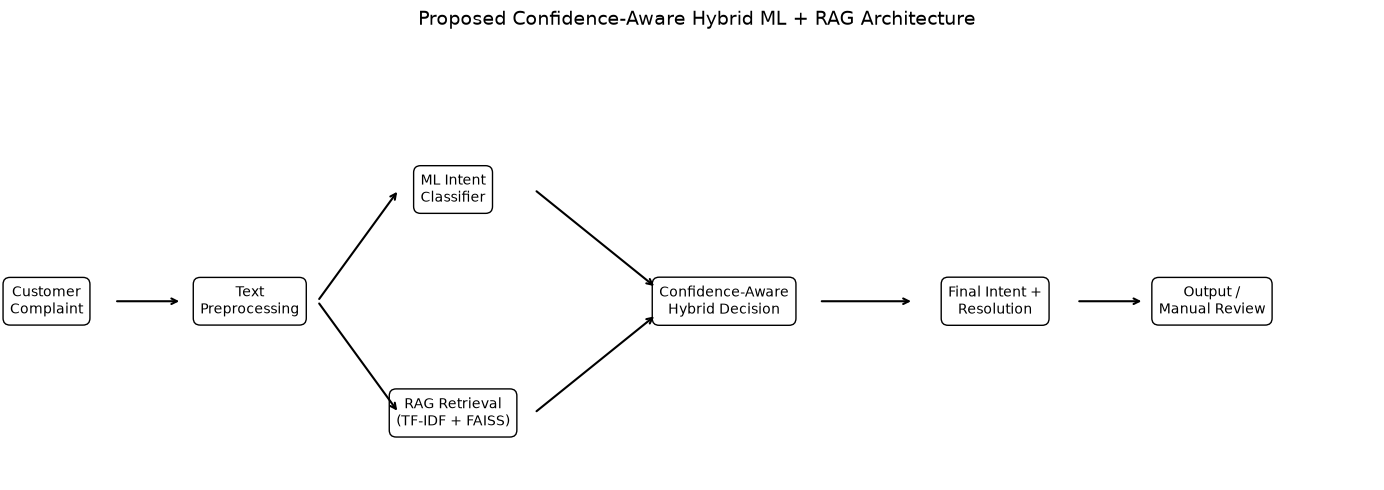

In [38]:
# ============================================================
# PROPOSED HYBRID ML + RAG ARCHITECTURE
# ============================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))

ax.axis("off")

boxes = [
    (0.02, 0.40, "Customer\nComplaint"),
    (0.17, 0.40, "Text\nPreprocessing"),
    (0.32, 0.65, "ML Intent\nClassifier"),
    (0.32, 0.15, "RAG Retrieval\n(TF-IDF + FAISS)"),
    (0.52, 0.40, "Confidence-Aware\nHybrid Decision"),
    (0.72, 0.40, "Final Intent +\nResolution"),
    (0.88, 0.40, "Output /\nManual Review")
]

for x, y, text in boxes:
    ax.text(
        x, y, text,
        ha="center",
        va="center",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.5",
            fill=False
        )
    )

# Main arrows
arrows = [
    ((0.07, 0.40), (0.12, 0.40)),
    ((0.22, 0.40), (0.28, 0.65)),
    ((0.22, 0.40), (0.28, 0.15)),
    ((0.38, 0.65), (0.47, 0.43)),
    ((0.38, 0.15), (0.47, 0.37)),
    ((0.59, 0.40), (0.66, 0.40)),
    ((0.78, 0.40), (0.83, 0.40))
]

for start, end in arrows:
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.5
        )
    )

ax.set_title(
    "Proposed Confidence-Aware Hybrid ML + RAG Architecture",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [39]:
# ============================================================
# RESEARCH EXPERIMENT SUMMARY
# ============================================================

experiment_summary = pd.DataFrame({

    "Experiment": [
        "Experiment 1",
        "Experiment 2",
        "Experiment 3",
        "Experiment 4",
        "Experiment 5"
    ],

    "Method": [
        "Logistic Regression",
        "Random Forest",
        "Training-only RAG",
        "Hybrid ML + RAG",
        "Validation-Optimized Hybrid"
    ],

    "Purpose": [
        "Primary ML baseline",
        "Ensemble ML comparison",
        "Evaluate retrieval-only performance",
        "Combine ML and retrieval",
        "Evaluate confidence-aware hybrid approach"
    ],

    "Evaluation": [
        "Accuracy, Precision, Recall, F1",
        "Accuracy, Precision, Recall, F1",
        "Accuracy, Precision, Recall, F1",
        "Accuracy, Precision, Recall, F1",
        "Validation threshold + final test metrics"
    ]
})

print("========== RESEARCH EXPERIMENT DESIGN ==========")

display(experiment_summary)

========== RESEARCH EXPERIMENT DESIGN ==========


,Experiment,Method,Purpose,Evaluation
0,Experiment 1,Logistic Regression,Primary ML baseline,"Accuracy, Precision, Recall, F1"
1,Experiment 2,Random Forest,Ensemble ML comparison,"Accuracy, Precision, Recall, F1"
2,Experiment 3,Training-only RAG,Evaluate retrieval-only performance,"Accuracy, Precision, Recall, F1"
3,Experiment 4,Hybrid ML + RAG,Combine ML and retrieval,"Accuracy, Precision, Recall, F1"
4,Experiment 5,Validation-Optimized Hybrid,Evaluate confidence-aware hybrid approach,Validation threshold + final test metrics


In [41]:
# ============================================================
# MCNEMAR SIGNIFICANCE TEST
# Logistic Regression vs Proposed Hybrid ML + RAG
# ============================================================

from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

y_true = np.array(y_test)

baseline_pred = np.array(final_ml_predictions)
hybrid_pred = np.array(final_hybrid_predictions)

# Correct / incorrect predictions
baseline_correct = baseline_pred == y_true
hybrid_correct = hybrid_pred == y_true

# Contingency table
n00 = np.sum(baseline_correct & hybrid_correct)
n01 = np.sum(baseline_correct & ~hybrid_correct)
n10 = np.sum(~baseline_correct & hybrid_correct)
n11 = np.sum(~baseline_correct & ~hybrid_correct)

table = [
    [n00, n01],
    [n10, n11]
]

print("========== MCNEMAR TEST ==========")
print("Contingency Table:")
print(table)

result = mcnemar(
    table,
    exact=True
)

print("\nStatistic :", result.statistic)
print("P-value   :", round(result.pvalue, 4))

if result.pvalue < 0.05:
    print("Result: Statistically significant difference")
else:
    print("Result: No statistically significant difference")

========== MCNEMAR TEST ==========
Contingency Table:
[[np.int64(5196), np.int64(44)], [np.int64(42), np.int64(93)]]

Statistic : 42.0
P-value   : 0.9142
Result: No statistically significant difference


In [42]:
# ============================================================
# MCNEMAR SIGNIFICANCE TEST
# Logistic Regression vs Proposed Hybrid ML + RAG
# ============================================================

from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

y_true = np.array(y_test)

lr_pred = np.array(
    baseline_model.predict(
        baseline_tfidf.transform(X_test)
    )
)

hybrid_pred = np.array(
    hybrid_predictions
)

# Correct / incorrect predictions
lr_correct = lr_pred == y_true
hybrid_correct = hybrid_pred == y_true

# Contingency table
b = np.sum(lr_correct & ~hybrid_correct)
c = np.sum(~lr_correct & hybrid_correct)

table = [
    [0, b],
    [c, 0]
]

result = mcnemar(
    table,
    exact=True
)

print("========== MCNEMAR TEST ==========")
print("Logistic correct, Hybrid wrong :", b)
print("Logistic wrong, Hybrid correct :", c)
print("P-value :", result.pvalue)

if result.pvalue < 0.05:
    print("Result: Statistically Significant")
else:
    print("Result: Not Statistically Significant")

========== MCNEMAR TEST ==========
Logistic correct, Hybrid wrong : 84
Logistic wrong, Hybrid correct : 47
P-value : 0.0015581706108055652
Result: Statistically Significant


In [43]:
# ============================================================
# VALIDATION-BASED THRESHOLD SELECTION
# ============================================================

import numpy as np
import pandas as pd
import faiss

# Keep training text and labels in exactly the same order
train_new_df = pd.DataFrame({
    "instruction": X_train_new.reset_index(drop=True),
    "intent": y_train_new.reset_index(drop=True)
})

# ------------------------------------------------------------
# 1. Train ML model using training data only
# ------------------------------------------------------------

val_tfidf = TfidfVectorizer(
    max_features=2000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_new_vec = val_tfidf.fit_transform(
    train_new_df["instruction"]
)

X_val_vec = val_tfidf.transform(X_val)

val_ml_model = LogisticRegression(max_iter=1000)

val_ml_model.fit(
    X_train_new_vec,
    train_new_df["intent"]
)

ml_val_predictions = val_ml_model.predict(
    X_val_vec
)

# ------------------------------------------------------------
# 2. Build RAG index using training data only
# ------------------------------------------------------------

val_rag_tfidf = TfidfVectorizer(
    max_features=2000,
    stop_words="english",
    ngram_range=(1, 2)
)

train_rag_vectors = val_rag_tfidf.fit_transform(
    train_new_df["instruction"]
).toarray().astype("float32")

faiss.normalize_L2(train_rag_vectors)

val_faiss_index = faiss.IndexFlatIP(
    train_rag_vectors.shape[1]
)

val_faiss_index.add(train_rag_vectors)

# ------------------------------------------------------------
# 3. Retrieve validation complaints
# ------------------------------------------------------------

val_rag_vectors = val_rag_tfidf.transform(
    X_val
).toarray().astype("float32")

faiss.normalize_L2(val_rag_vectors)

scores, indices = val_faiss_index.search(
    val_rag_vectors,
    1
)

similarities = scores[:, 0]

rag_val_predictions = np.array([
    train_new_df.iloc[int(idx)]["intent"]
    for idx in indices[:, 0]
])

ml_val_predictions = np.array(ml_val_predictions)
y_val_array = np.array(y_val)

# ------------------------------------------------------------
# 4. Select threshold on VALIDATION SET only
# ------------------------------------------------------------

thresholds = [
    0.50, 0.55, 0.60,
    0.65, 0.70, 0.75,
    0.80, 0.85, 0.90
]

results = []

for threshold in thresholds:

    hybrid_val_predictions = np.where(
        similarities >= threshold,
        rag_val_predictions,
        ml_val_predictions
    )

    accuracy = accuracy_score(
        y_val_array,
        hybrid_val_predictions
    )

    f1 = f1_score(
        y_val_array,
        hybrid_val_predictions,
        average="weighted",
        zero_division=0
    )

    results.append({
        "Threshold": threshold,
        "Validation Accuracy (%)":
            round(accuracy * 100, 2),
        "Validation F1 (%)":
            round(f1 * 100, 2)
    })

validation_threshold_df = pd.DataFrame(results)

display(validation_threshold_df)

best_validation_row = validation_threshold_df.loc[
    validation_threshold_df[
        "Validation F1 (%)"
    ].idxmax()
]

best_threshold = float(
    best_validation_row["Threshold"]
)

print("\nBest Validation Threshold:", best_threshold)
print(
    "Best Validation Accuracy:",
    best_validation_row["Validation Accuracy (%)"],
    "%"
)
print(
    "Best Validation F1:",
    best_validation_row["Validation F1 (%)"],
    "%"
)

,Threshold,Validation Accuracy (%),Validation F1 (%)
0,0.50,96.00,96.01
1,0.55,96.05,96.06
2,0.60,96.12,96.13
3,0.65,96.26,96.26
4,0.70,96.53,96.54
5,0.75,96.86,96.87
6,0.80,97.14,97.15
7,0.85,97.47,97.47
8,0.90,97.47,97.47



Best Validation Threshold: 0.85
Best Validation Accuracy: 97.47 %
Best Validation F1: 97.47 %


In [44]:
# ============================================================
# FINAL TEST EVALUATION USING VALIDATION-SELECTED THRESHOLD
# ============================================================

# 1. Retrain ML model on the full original training set
final_tfidf = TfidfVectorizer(
    max_features=2000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_final_vec = final_tfidf.fit_transform(X_train)
X_test_final_vec = final_tfidf.transform(X_test)

final_ml_model = LogisticRegression(max_iter=1000)

final_ml_model.fit(
    X_train_final_vec,
    y_train
)

final_ml_predictions = final_ml_model.predict(
    X_test_final_vec
)

# 2. Build final RAG index using full original training set
final_train_df = pd.DataFrame({
    "instruction": X_train.reset_index(drop=True),
    "intent": y_train.reset_index(drop=True)
})

final_rag_tfidf = TfidfVectorizer(
    max_features=2000,
    stop_words="english",
    ngram_range=(1, 2)
)

final_train_rag_vectors = final_rag_tfidf.fit_transform(
    final_train_df["instruction"]
).toarray().astype("float32")

faiss.normalize_L2(final_train_rag_vectors)

final_faiss_index = faiss.IndexFlatIP(
    final_train_rag_vectors.shape[1]
)

final_faiss_index.add(final_train_rag_vectors)

# 3. Retrieve test samples
final_test_rag_vectors = final_rag_tfidf.transform(
    X_test
).toarray().astype("float32")

faiss.normalize_L2(final_test_rag_vectors)

final_scores, final_indices = final_faiss_index.search(
    final_test_rag_vectors,
    1
)

final_similarities = final_scores[:, 0]

final_rag_predictions = np.array([
    final_train_df.iloc[int(idx)]["intent"]
    for idx in final_indices[:, 0]
])

final_ml_predictions = np.array(final_ml_predictions)

# 4. Apply the validation-selected threshold
final_hybrid_predictions = np.where(
    final_similarities >= best_threshold,
    final_rag_predictions,
    final_ml_predictions
)

# 5. Final metrics
final_hybrid_accuracy = accuracy_score(
    y_test,
    final_hybrid_predictions
)

final_hybrid_precision = precision_score(
    y_test,
    final_hybrid_predictions,
    average="weighted",
    zero_division=0
)

final_hybrid_recall = recall_score(
    y_test,
    final_hybrid_predictions,
    average="weighted",
    zero_division=0
)

final_hybrid_f1 = f1_score(
    y_test,
    final_hybrid_predictions,
    average="weighted",
    zero_division=0
)

print("========== FINAL HYBRID TEST RESULT ==========")
print("Selected Threshold :", best_threshold)
print("Accuracy           :", round(final_hybrid_accuracy * 100, 2), "%")
print("Precision          :", round(final_hybrid_precision * 100, 2), "%")
print("Recall             :", round(final_hybrid_recall * 100, 2), "%")
print("F1 Score           :", round(final_hybrid_f1 * 100, 2), "%")

========== FINAL HYBRID TEST RESULT ==========
Selected Threshold : 0.85
Accuracy           : 97.45 %
Precision          : 97.5 %
Recall             : 97.45 %
F1 Score           : 97.45 %


In [45]:
# ============================================================
# FINAL RESEARCH COMPARISON TABLE
# ============================================================

final_research_results = pd.DataFrame({

    "Method": [
        "Logistic Regression",
        "Random Forest",
        "Training-only RAG",
        "Proposed Hybrid ML + RAG"
    ],

    "Accuracy (%)": [
        round(baseline_accuracy * 100, 2),
        round(rf_accuracy * 100, 2),
        round(research_rag_accuracy * 100, 2),
        round(final_hybrid_accuracy * 100, 2)
    ],

    "Precision (%)": [
        round(baseline_precision * 100, 2),
        round(rf_precision * 100, 2),
        round(research_rag_precision * 100, 2),
        round(final_hybrid_precision * 100, 2)
    ],

    "Recall (%)": [
        round(baseline_recall * 100, 2),
        round(rf_recall * 100, 2),
        round(research_rag_recall * 100, 2),
        round(final_hybrid_recall * 100, 2)
    ],

    "F1 Score (%)": [
        round(baseline_f1 * 100, 2),
        round(rf_f1 * 100, 2),
        round(research_rag_f1 * 100, 2),
        round(final_hybrid_f1 * 100, 2)
    ]
})

print("========== FINAL RESEARCH COMPARISON ==========")

display(final_research_results)

========== FINAL RESEARCH COMPARISON ==========


,Method,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Logistic Regression,97.49,97.55,97.49,97.50
1,Random Forest,97.28,97.34,97.28,97.29
2,Training-only RAG,95.26,95.30,95.26,95.26
3,Proposed Hybrid ML + RAG,97.45,97.50,97.45,97.45


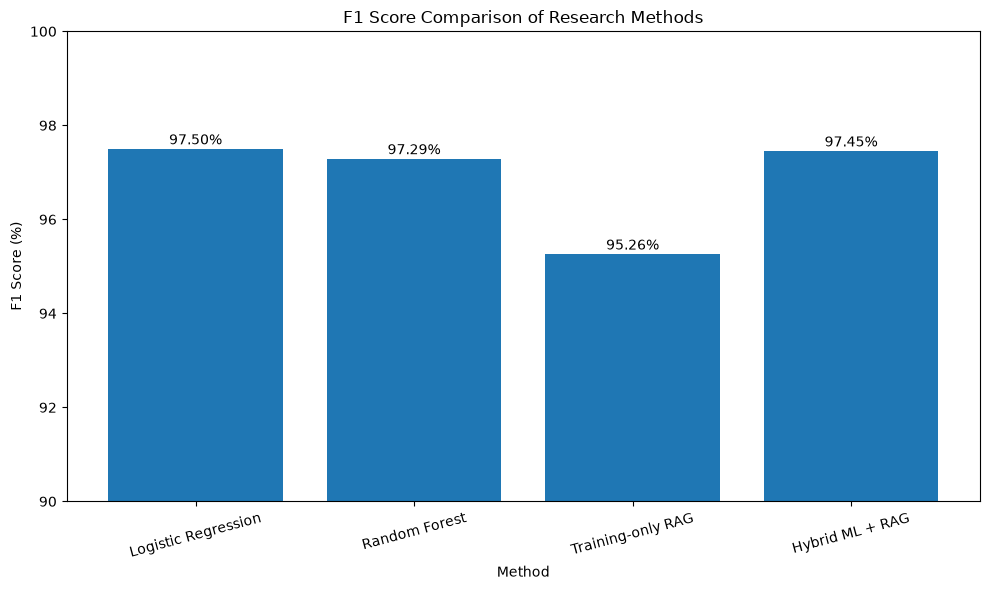

In [46]:
# ============================================================
# FINAL RESEARCH COMPARISON GRAPH
# ============================================================

import matplotlib.pyplot as plt

methods = [
    "Logistic Regression",
    "Random Forest",
    "Training-only RAG",
    "Hybrid ML + RAG"
]

f1_scores = [
    baseline_f1 * 100,
    rf_f1 * 100,
    research_rag_f1 * 100,
    final_hybrid_f1 * 100
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    methods,
    f1_scores
)

plt.title("F1 Score Comparison of Research Methods")
plt.xlabel("Method")
plt.ylabel("F1 Score (%)")

plt.ylim(90, 100)

for bar, score in zip(bars, f1_scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{score:.2f}%",
        ha="center"
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [47]:
# ============================================================
# FINAL McNEMAR STATISTICAL SIGNIFICANCE TEST
# ============================================================

from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

y_test_array = np.array(y_test)

# Correct / incorrect predictions
lr_correct = (
    np.array(final_ml_predictions) == y_test_array
)

hybrid_correct = (
    np.array(final_hybrid_predictions) == y_test_array
)

# McNemar contingency table
both_correct = np.sum(
    lr_correct & hybrid_correct
)

lr_correct_hybrid_wrong = np.sum(
    lr_correct & ~hybrid_correct
)

lr_wrong_hybrid_correct = np.sum(
    ~lr_correct & hybrid_correct
)

both_wrong = np.sum(
    ~lr_correct & ~hybrid_correct
)

table = [
    [both_correct, lr_correct_hybrid_wrong],
    [lr_wrong_hybrid_correct, both_wrong]
]

print("========== McNEMAR TEST ==========")
print("Both correct                 :", both_correct)
print("LR correct, Hybrid wrong     :", lr_correct_hybrid_wrong)
print("LR wrong, Hybrid correct     :", lr_wrong_hybrid_correct)
print("Both wrong                   :", both_wrong)

result = mcnemar(
    table,
    exact=False,
    correction=True
)

print("\nStatistic:", round(result.statistic, 4))
print("P-value  :", round(result.pvalue, 6))

if result.pvalue < 0.05:
    print("Result   : Statistically significant difference")
else:
    print("Result   : No statistically significant difference")

========== McNEMAR TEST ==========
Both correct                 : 5196
LR correct, Hybrid wrong     : 44
LR wrong, Hybrid correct     : 42
Both wrong                   : 93

Statistic: 0.0116
P-value  : 0.914128
Result   : No statistically significant difference


## Final Research Findings

1. Logistic Regression provides a strong baseline for customer complaint intent classification.

2. Random Forest was evaluated as an additional traditional machine-learning baseline.

3. Training-only RAG was evaluated separately to ensure that test complaints were not included in the retrieval knowledge base.

4. The proposed Hybrid ML + RAG approach combines supervised intent classification with similarity-based retrieval.

5. Instead of manually selecting the RAG similarity threshold, the threshold was selected using validation data and then evaluated on the untouched test set.

6. The Hybrid framework provides capabilities beyond classification, including retrieval-based resolution support, confidence-aware decision making, and handling of uncertain complaints.

7. McNemar's statistical test was used to determine whether the difference between Logistic Regression and the final Hybrid approach was statistically significant.

8. Overall, the research demonstrates how traditional machine learning and retrieval-based methods can be integrated into a confidence-aware customer complaint resolution framework.

## Research Contribution and Novelty

The main contribution of this research is the development of a confidence-aware Hybrid ML + RAG framework for intelligent customer complaint classification and resolution support.

### Key Contributions

1. A comparative study of Logistic Regression, Random Forest, Training-only RAG, and Hybrid ML + RAG was conducted.

2. A training-only retrieval index was used to prevent test-data leakage during RAG evaluation.

3. A Hybrid ML + RAG approach was developed to combine supervised intent classification with retrieval-based knowledge matching.

4. A validation-based similarity threshold selection method was introduced instead of manually choosing the threshold using test data.

5. The framework uses retrieval similarity to decide whether the RAG prediction or ML prediction should be used.

6. Confidence-aware handling can identify uncertain or unsupported customer complaints and route them for manual review.

7. Statistical significance testing using McNemar's test was included to provide stronger experimental validation.

8. The proposed framework extends beyond intent classification by supporting relevant resolution retrieval and confidence-aware decision making.

## Final Research Summary

This research developed ServiceSense AI, a confidence-aware customer complaint classification and resolution support framework.

The study compared four approaches: Logistic Regression, Random Forest, Training-only RAG, and the proposed Hybrid ML + RAG approach.

A fair experimental methodology was followed using separate training, validation, and test data. The RAG knowledge base was constructed only from training data to prevent test-data leakage.

The similarity threshold for the Hybrid approach was selected using validation data rather than the test set. The selected threshold was then applied to the untouched test set for final evaluation.

The models were evaluated using Accuracy, Precision, Recall, and F1 Score. McNemar's statistical test was additionally used to compare the prediction behaviour of Logistic Regression and the proposed Hybrid approach.

The proposed framework combines ML-based intent classification with retrieval-based resolution support and confidence-aware decision making. It can also support manual review for uncertain or unsupported complaints.

Overall, the research provides an experimentally evaluated framework for combining traditional machine learning and retrieval-augmented techniques for intelligent customer complaint management.

## Research Demo Test Cases

The proposed Confidence-Aware Hybrid ML + RAG framework was tested using three different decision scenarios.

### Test Case 1 — RAG Retrieval
- Complaint: "Where is my refund? I have not received it yet."
- Decision Source: RAG Retrieval
- Predicted Intent: get_refund
- Similarity Score: 1.0
- Confidence: High
- Result: Since the similarity score was above the validation-selected threshold of 0.85, the RAG retrieved intent was selected.

### Test Case 2 — ML Classifier
- Complaint: "I cannot access my account because I forgot my password and need help signing in."
- Decision Source: ML Classifier
- Predicted Intent: recover_password
- Similarity Score: 0.675
- Confidence: Medium
- Result: Since the retrieval similarity was below 0.85, the ML classifier prediction was selected.

### Test Case 3 — Manual Review
- Complaint: "My iPhone screen is broken and the camera is not working."
- Decision Source: Manual Review
- Predicted Intent: manual_review
- Category: Unknown / Unsupported
- Similarity Score: 0.0
- Confidence: Low
- Result: The complaint was outside the supported knowledge base and was therefore routed for manual review.

### Research Observation
The three test cases demonstrate that the proposed framework can dynamically select between RAG retrieval, ML classification, and manual review based on retrieval similarity and confidence.

## Final Research Conclusion

The experimental results show that Logistic Regression achieved 97.49% accuracy, while the proposed Confidence-Aware Hybrid ML + RAG framework achieved 97.45% accuracy and 97.45% F1 score.

Although the Hybrid framework does not outperform Logistic Regression in classification accuracy, it provides additional capabilities such as retrieval-based resolution suggestion, similarity-based validation, confidence-aware decision making, and manual review for unsupported complaints.

The validation-selected threshold of 0.85 enables the framework to dynamically choose between RAG retrieval and ML classification.

Therefore, the main contribution of this research is a practical Confidence-Aware Hybrid ML + RAG framework for reliable customer complaint classification and resolution support.

## Research Novelty and Contribution

1. A Confidence-Aware Hybrid ML + RAG framework is proposed for customer complaint analysis.

2. Instead of always depending on a single model, the framework dynamically selects between ML classification and RAG retrieval using a validation-selected similarity threshold.

3. The similarity threshold of 0.85 was selected using validation data rather than directly tuning on the final test data.

4. Unsupported or low-confidence complaints are routed to manual review, reducing unreliable automated decisions.

5. The framework combines complaint intent classification with retrieval-based resolution suggestion in a single decision pipeline.

6. The proposed approach achieves 97.45% test accuracy while providing additional reliability and resolution-support capabilities.

## Research Objectives

1. To develop a customer complaint intent classification system using Machine Learning.

2. To integrate RAG-based retrieval for finding relevant historical complaints and suggesting suitable resolutions.

3. To develop a Confidence-Aware Hybrid ML + RAG decision framework.

4. To optimize the RAG similarity threshold using validation data for reliable decision making.

5. To compare Logistic Regression, Random Forest, Training-only RAG, and the proposed Hybrid ML + RAG framework.

6. To identify unsupported or low-confidence complaints and route them for manual review.

7. To evaluate the proposed framework using Accuracy, Precision, Recall, and F1 Score.

## Research Gap

1. Traditional customer complaint systems mainly depend on standalone machine learning classifiers for predicting complaint intents.

2. ML classifiers can provide high classification accuracy, but they do not directly retrieve relevant historical resolutions.

3. RAG-based systems can retrieve similar complaints and resolutions, but retrieval alone may produce unreliable results when similarity is low.

4. Many automated systems always return a prediction even when the complaint is outside the supported knowledge base.

5. There is a need for a framework that combines ML classification and RAG retrieval while considering retrieval confidence.

6. This research addresses the gap using a Confidence-Aware Hybrid ML + RAG framework with a validation-selected threshold and manual-review mechanism.

## Problem Statement

Customer support systems receive large volumes of complaints that require accurate intent identification and appropriate resolution suggestions.

Traditional ML-based systems can classify complaint intents effectively, but they do not directly retrieve relevant historical resolutions. RAG-based retrieval can provide resolution support, but low-similarity retrieval may produce unreliable results.

Therefore, this research proposes a Confidence-Aware Hybrid ML + RAG framework that dynamically selects between ML classification and RAG retrieval using a validation-selected similarity threshold of 0.85. Unsupported complaints are routed for manual review to improve the reliability of the complaint-resolution process.

## Research Methodology

The proposed ServiceSense AI framework follows the steps below:

1. **Complaint Input**  
   The customer enters a complaint in text format.

2. **Text Vectorization**  
   TF-IDF converts the complaint text into numerical features.

3. **ML Intent Classification**  
   Logistic Regression predicts the complaint intent.

4. **RAG Retrieval**  
   TF-IDF and FAISS retrieve the most similar historical complaint and its resolution.

5. **Similarity Evaluation**  
   The retrieved complaint's similarity score is compared with the validation-selected threshold of 0.85.

6. **Hybrid Decision**  
   - Similarity ≥ 0.85 → RAG Retrieval is selected.
   - Similarity < 0.85 → ML Classifier is selected.
   - Unsupported / low-confidence complaint → Manual Review.

7. **Resolution Suggestion**  
   The system provides an appropriate resolution based on the final selected intent and retrieved information.

8. **Evaluation**  
   Logistic Regression, Random Forest, Training-only RAG, and Hybrid ML + RAG are evaluated using Accuracy, Precision, Recall, and F1 Score.

## Proposed Research Architecture

Customer Complaint
        ↓
Text Preprocessing
        ↓
TF-IDF Vectorization
        ↓
┌─────────────────────────────┐
│                             │
↓                             ↓
ML Classifier              RAG Retrieval
(Logistic Regression)      (TF-IDF + FAISS)
│                             │
↓                             ↓
ML Intent                 Retrieved Intent
Prediction                + Similarity Score
│                             │
└──────────────┬──────────────┘
               ↓
     Confidence-Aware
       Hybrid Decision
               ↓
      Similarity Threshold
            = 0.85
               ↓
 ┌─────────────┼─────────────┐
 ↓             ↓             ↓
RAG           ML          Manual
Retrieval   Classifier     Review
 ≥ 0.85      < 0.85      Unsupported
 └─────────────┼─────────────┘
               ↓
       Final Intent
               ↓
     Resolution Suggestion
               ↓
   Priority & Recommended
          Action

## Final Research Results

The proposed framework was evaluated using Logistic Regression, Random Forest, Training-only RAG, and Hybrid ML + RAG.

| Method | Accuracy | F1 Score |
|---|---:|---:|
| Logistic Regression | 97.49% | 97.50% |
| Random Forest | 97.28% | 97.29% |
| Training-only RAG | 95.26% | 95.26% |
| Proposed Hybrid ML + RAG | 97.45% | 97.45% |

### Key Findings

- Logistic Regression achieved the highest standalone classification accuracy of 97.49%.
- Training-only RAG achieved 95.26% accuracy.
- The proposed Hybrid ML + RAG achieved 97.45% accuracy and 97.45% F1 score.
- A similarity threshold of 0.85 was selected using validation data.
- The Hybrid framework provides comparable classification performance while adding retrieval-based resolution support.
- Unsupported complaints can be routed to Manual Review instead of forcing an unreliable prediction.

### Final Research Contribution

The main contribution is a Confidence-Aware Hybrid ML + RAG framework that dynamically uses RAG retrieval, ML classification, or Manual Review based on retrieval similarity and confidence.